In [2]:
import warnings
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes, fetch_openml,load_iris,fetch_california_housing
from sklearn.feature_selection import mutual_info_regression, f_regression, RFE, SelectFromModel, SelectKBest, f_classif
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import (
RepeatedStratifiedKFold, 
cross_val_score, 
train_test_split, 
GridSearchCV,
cross_val_predict, 
learning_curve, 
validation_curve)
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error,zero_one_loss, roc_auc_score,root_mean_squared_error
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.decomposition import PCA
from sklearn.datasets import make_circles, make_moons, make_blobs
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from os.path import join as pjoin
from sklearn.feature_extraction.text import TfidfVectorizer
#sharper plots
%config InlineBackend.figure_format = 'retina'
from sklearn.preprocessing import MinMaxScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

from sklearn.linear_model import (LogisticRegression, LogisticRegressionCV,
                                  SGDClassifier)

warnings.filterwarnings("ignore")


# Методы интерпретации
Существует множество способов разделить методы интерпретации. Например, интерпретируемые по модели, когда интерпретация заложена в структуру, или методы черного ящика, которые применяются уже после обучения модели (например, когда модель слишком сложная).

Кроме того, методы можно поделить на локальные - когда мы пытаемся объяснить предсказание для одного объекта, и глобальные - когда модель анализируется в целом.

Еще один вариант - разделение по  предназначению - применяются методы к конкретным классим модели или универсальные. Например, transformer circuits -  model specific методы.

Частично мы уже обсудили интерпретацию - рассмотрели интерпретируемые по определению модели (линейную  и дерево), а также методы для оценки важности признаков. Как можно классифицировать те методы?

# Графические методы

Наиболее информативная часть данных методов сосредоточена в графиках. Разберем три из них - ICE, PDP и ALE.

Для демонстрации методов будем использовать датасет MAGIC (Major Atmospheric Gamma Imaging Cherenkov). Это датасет для бинарной классификации гамма-лучей (signal) и адронов (background).

In [3]:

data_path = "../data/"
columns = np.array(["Length", "Width", "Size", "Conc", "Conc1", "Asym", "M3Long", "M3Trans", "Alpha", "Dist"])

data = pd.read_csv(pjoin(data_path, "magic.txt"), header=None, names=list(columns)+["Label"])

X = data[columns].values
y = 1 * (data['Label'].values == "g")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print(f"Доля класса gamma (signal): {y_train.mean():.3f}")


# Масштабирование
sc = MinMaxScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

Размер обучающей выборки: 13314
Размер тестовой выборки: 5706
Доля класса gamma (signal): 0.648


In [4]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Accuracy: 0.8705
ROC-AUC: 0.9243


## ICE

**Individual Conditional Expectation (ICE)** - графики индивидуального условного ожидания. В этом методе мы оцениваем, как меняется предсказание для изменения конкретного признака для каждого объекта в некотором наборе $x_{test}$.

Алгоритм:
1) Зафиксируем множество $X_{test}$ и некоторый признак $j$. Пусть $j$ имеет $m$ уникальных значений $[j_1, j_2, \ldots, j_m]$.
2) Исходный датасет $X_{test}$ дублируем $m$ раз: 
    $[X'_1, X'_2, \ldots, X'_m] $
    так, что для датасета $X'_i$ значение признака $j$ фиксируется равным $j_i$.
3) На каждом $X'_i$ рассчитываем прогноз модели $f(X'_i)$.
4) На графике строим линии для каждого объекта, показывающие, 
    как прогноз (ось $y$) меняется при изменении признака (ось $x$).

**Центрированные ICE (c-ICE):**
Для лучшей визуализации часто используют центрированные ICE кривые, которые начинаются с нуля:

$$f_i^{centered}(x_S) = f_i(x_S) - f_i(x_{S,min})$$

где $x_{S,min}$ - минимальное значение признака $S$ в обучающей выборке.

ICE реализован в sklearn. Воспользуемся им.

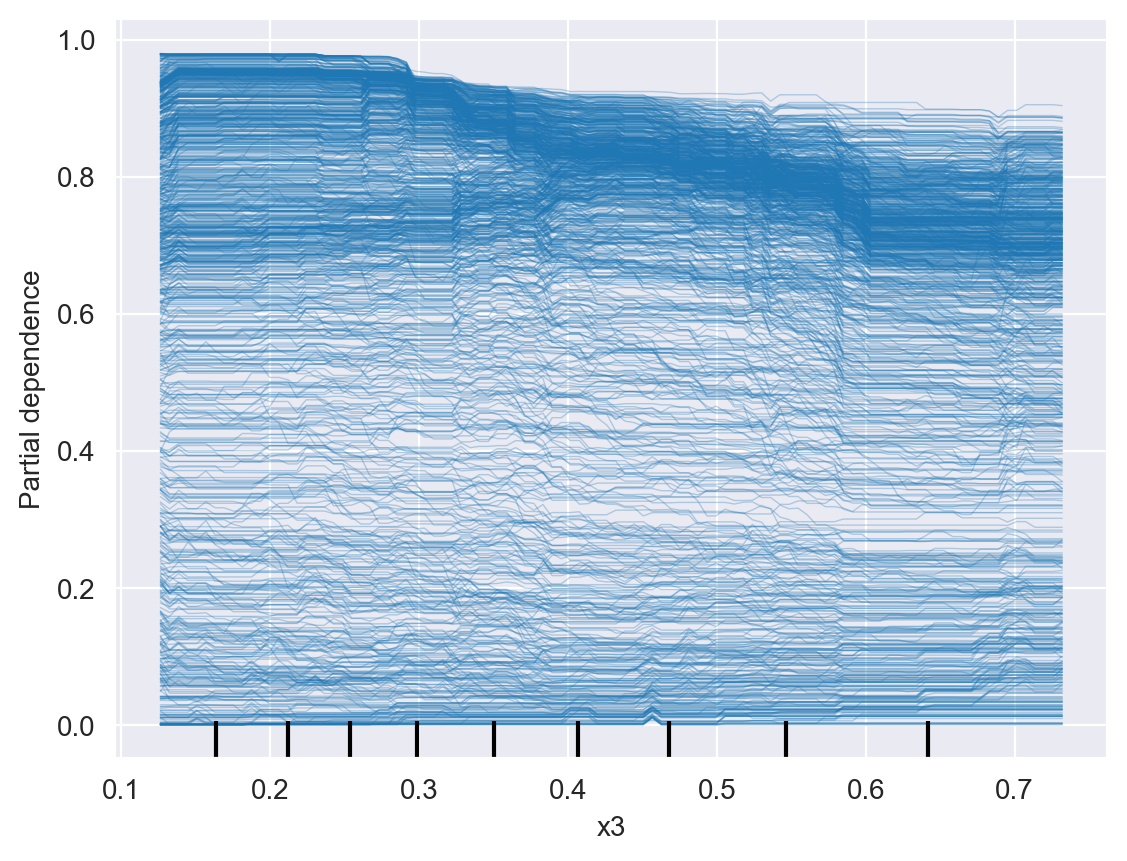

In [5]:

from sklearn.inspection import PartialDependenceDisplay


feature_idx = 3

PartialDependenceDisplay.from_estimator(rf, X_test, [feature_idx],
   kind='individual')

Хотя ICE очень доступны и понятны, они обладают рядом ограничений:

- Построение ICE использует предположение о независимости признаков;
- В случае большого количества объектов в наборе данных график ICE оказывается нечитаемым. Иногда ICE становится читаемее и информативнее, если раскрашивать кривые по, например, уровням какого-то признака или кластерам объектов.
- ICE не дает централизованной оценки, которую можно измерить. У этой проблемы есть решение — рассмотрение ICE в паре c PDP.

## Partial Dependence Plots (PDP)

**Partial Dependence Plot (PDP)** показывает среднее влияние признака на предсказание модели, усредняя по всем остальным признакам.

Математически PDP для признака $S$ определяется как:

$$f_S(x_S) = E_{X_C}[f(x_S, X_C)] = \int f(x_S, x_C) dP(x_C)$$

где:
- $x_S$ - значение интересующего признака (признаков)
- $X_C$ - остальные признаки
- $f$ - функция модели
- $P(x_C)$ - маргинальное распределение остальных признаков

**Алгоритм вычисления PDP:**

1. Для каждого значения $x_S$ из интересующего диапазона:
   - Зафиксировать $x_S$
   - Для каждого объекта из обучающей выборки заменить значение признака $S$ на $x_S$
   - Вычислить предсказания модели для всех модифицированных объектов
   - Усреднить предсказания

Partial Dependence plot является логическим продолжением ICE, а именно — усредняет его оценку. Это глобальная интерпретация и она также реализована в sklearn, в том числе в двумерном виде.

In [6]:
feature_idx_alpha = list(columns).index("Alpha")
feature_idx_length = list(columns).index("Length")
feature_idx_width = list(columns).index("Width")

pdp_alpha = partial_dependence(
    rf, X_train, features=[feature_idx_alpha],
    grid_resolution=50, kind='average'
)

pdp_length = partial_dependence(
    rf, X_train, features=[feature_idx_length],
    grid_resolution=50, kind='average'
)

pdp_width = partial_dependence(
    rf, X_train, features=[feature_idx_width],
    grid_resolution=50, kind='average'
)


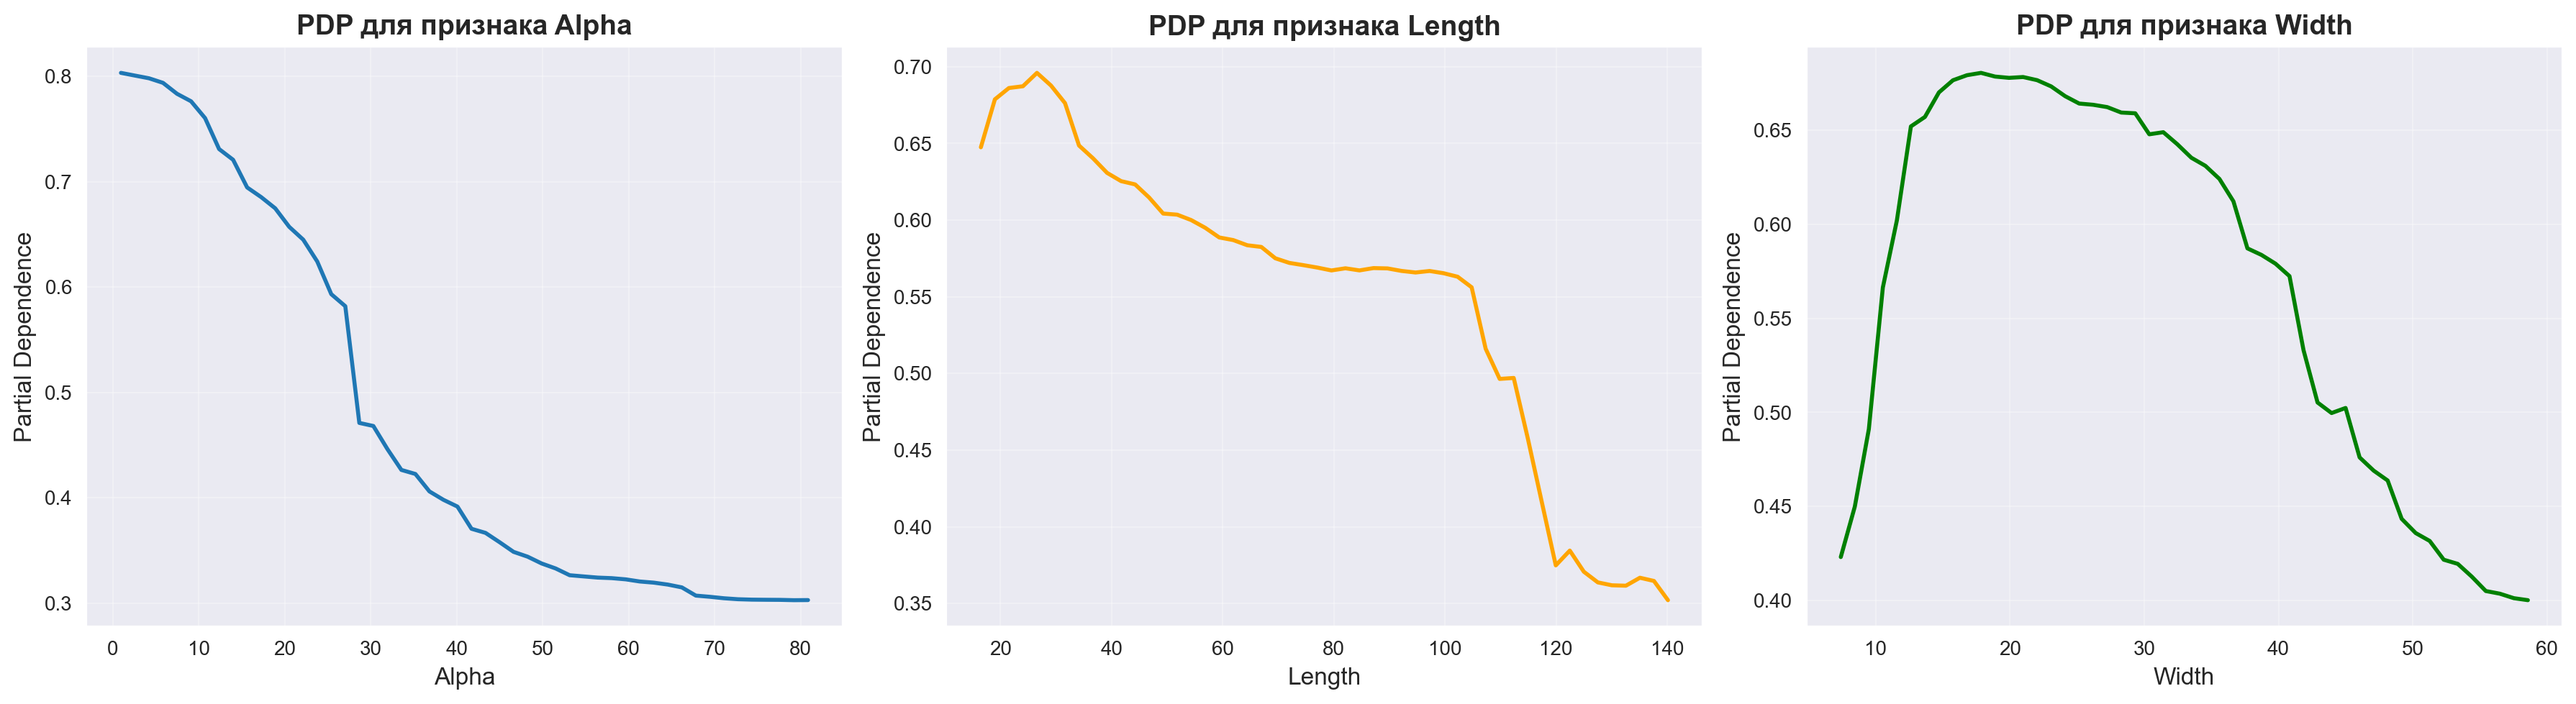

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(pdp_alpha['grid_values'][0], pdp_alpha['average'][0], linewidth=2)
axes[0].set_xlabel('Alpha', fontsize=12)
axes[0].set_ylabel('Partial Dependence', fontsize=12)
axes[0].set_title('PDP для признака Alpha', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(pdp_length['grid_values'][0], pdp_length['average'][0], linewidth=2, color='orange')
axes[1].set_xlabel('Length', fontsize=12)
axes[1].set_ylabel('Partial Dependence', fontsize=12)
axes[1].set_title('PDP для признака Length', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(pdp_width['grid_values'][0], pdp_width['average'][0], linewidth=2, color='green')
axes[2].set_xlabel('Width', fontsize=12)
axes[2].set_ylabel('Partial Dependence', fontsize=12)
axes[2].set_title('PDP для признака Width', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


PDP позволяет также сделать дополнительные выводы о взаимодействии признаков между собой. Полностью прямые линии говорят, что взаимодействия нет (либо один признак вообще не имеет влияния в модели). Однако PDP никак не учитывает распределение признака по группам, и если для одной группы прогноз растет, а для другой падает, мы не увидим никакого влияния. Здесь возможным решением может быть построение графиков отдельно для разных групп или предварительный анализ ICE.

Задание: Постройте графики ICE, PDP для признаков LotFrontage, GarageArea  набора данных realestate из прошлогодних практик с учетом разбиения по районам (Neighborhood) и без него. Заметна ли проблема усреднения?

Кроме того, PDP также, как и  ICE предполагает независимость признаков, поэтому может приводить к некорректным выводам. 

In [83]:
def load_and_prepare_data():
    data = pd.read_csv("../data/realestate.txt", sep="\t")
    
    features = ['SqFeet', 'Garage', 'Year', 'Quality', 'Style']
    target = 'SalePrice'
    
    X = data[features].values
    y = data[target].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return data, X_train_scaled, X_test_scaled, y_train, y_test, features

def train_model(X_train, y_train):
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    rf.fit(X_train, y_train)
    return rf

In [84]:
def plot_pdp_ice(model, X, feature_names, feature_idx, title_prefix, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    pdp = partial_dependence(model, X, [feature_idx], kind='average')
    ax[0].plot(pdp['grid_values'][0], pdp['average'][0], linewidth=2, color='blue')
    ax[0].set_xlabel(feature_names[feature_idx])
    ax[0].set_ylabel('Partial Dependence')
    ax[0].set_title(f'PDP: {title_prefix}')
    ax[0].grid(True, alpha=0.3)
    
    PartialDependenceDisplay.from_estimator(
        model, X[:50], [feature_idx], kind='individual', 
        ax=ax[1], line_kw={'alpha': 0.5, 'color': 'gray'}
    )
    ax[1].set_xlabel(feature_names[feature_idx])
    ax[1].set_ylabel('Predicted Price')
    ax[1].set_title(f'ICE: {title_prefix}')
    ax[1].grid(True, alpha=0.3)
    
    return ax

In [85]:
def plot_pdp_by_neighborhood(model, X_train_df, features, feature_idx, neighborhood_col, title_prefix):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    unique_neighborhoods = np.unique(X_train_df[neighborhood_col])[:5]
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_neighborhoods)))
    
    for nhood, color in zip(unique_neighborhoods, colors):
        mask = X_train_df[neighborhood_col] == nhood
        if mask.sum() > 10:
            X_subset = X_train_df[mask][features].values
            pdp = partial_dependence(model, X_subset, [feature_idx], kind='average')
            ax[0].plot(pdp['grid_values'][0], pdp['average'][0], 
                      linewidth=1.5, color=color, label=f'{nhood}')
    
    ax[0].set_xlabel(features[feature_idx])
    ax[0].set_ylabel('Partial Dependence')
    ax[0].set_title(f'PDP с разбивкой: {title_prefix}')
    ax[0].grid(True, alpha=0.3)
    ax[0].legend(loc='best', fontsize=8)
    
    for nhood, color in zip(unique_neighborhoods, colors):
        mask = X_train_df[neighborhood_col] == nhood
        if mask.sum() > 10:
            X_subset = X_train_df[mask][features].values[:30]
            PartialDependenceDisplay.from_estimator(
                model, X_subset, [feature_idx], kind='individual',
                ax=ax[1], line_kw={'alpha': 0.5, 'color': color}
            )
    
    ax[1].set_xlabel(features[feature_idx])
    ax[1].set_ylabel('Predicted Price')
    ax[1].set_title(f'ICE с разбивкой: {title_prefix}')
    ax[1].grid(True, alpha=0.3)
    
    return fig

In [86]:
def compare_pdp(model, X_train_df, features, feature_idx, neighborhood_col, title_prefix):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    pdp_global = partial_dependence(model, X_train_df[features].values, [feature_idx], kind='average')
    ax[0].plot(pdp_global['grid_values'][0], pdp_global['average'][0], 
              linewidth=2, label='Без учета районов', linestyle='--', color='red')
    
    unique_neighborhoods = np.unique(X_train_df[neighborhood_col])[:5]
    for nhood in unique_neighborhoods:
        mask = X_train_df[neighborhood_col] == nhood
        if mask.sum() > 10:
            X_subset = X_train_df[mask][features].values
            pdp = partial_dependence(model, X_subset, [feature_idx], kind='average')
            ax[0].plot(pdp['grid_values'][0], pdp['average'][0], 
                      linewidth=1, alpha=0.7, label=f'Район {nhood}')
    
    ax[0].set_xlabel(features[feature_idx])
    ax[0].set_ylabel('Partial Dependence')
    ax[0].set_title(f'Сравнение PDP: {title_prefix}')
    ax[0].grid(True, alpha=0.3)
    ax[0].legend(loc='best', fontsize=8)
    
    ax[1].plot(pdp_global['grid_values'][0], pdp_global['average'][0], 
              linewidth=3, label='PDP (усредненный)', color='red')
    
    X_subset = X_train_df[features].values[:30]
    PartialDependenceDisplay.from_estimator(
        model, X_subset, [feature_idx], kind='individual',
        ax=ax[1], line_kw={'alpha': 0.5, 'color': 'gray'}
    )
    
    ax[1].set_xlabel(features[feature_idx])
    ax[1].set_ylabel('Predicted Price')
    ax[1].set_title(f'Проблема усреднения: {title_prefix}')
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()
    
    return fig

In [87]:
data, X_train, X_test, y_train, y_test, features = load_and_prepare_data()
model = train_model(X_train, y_train)

lot_idx = features.index('SqFeet')  
garage_idx = features.index('Garage')  

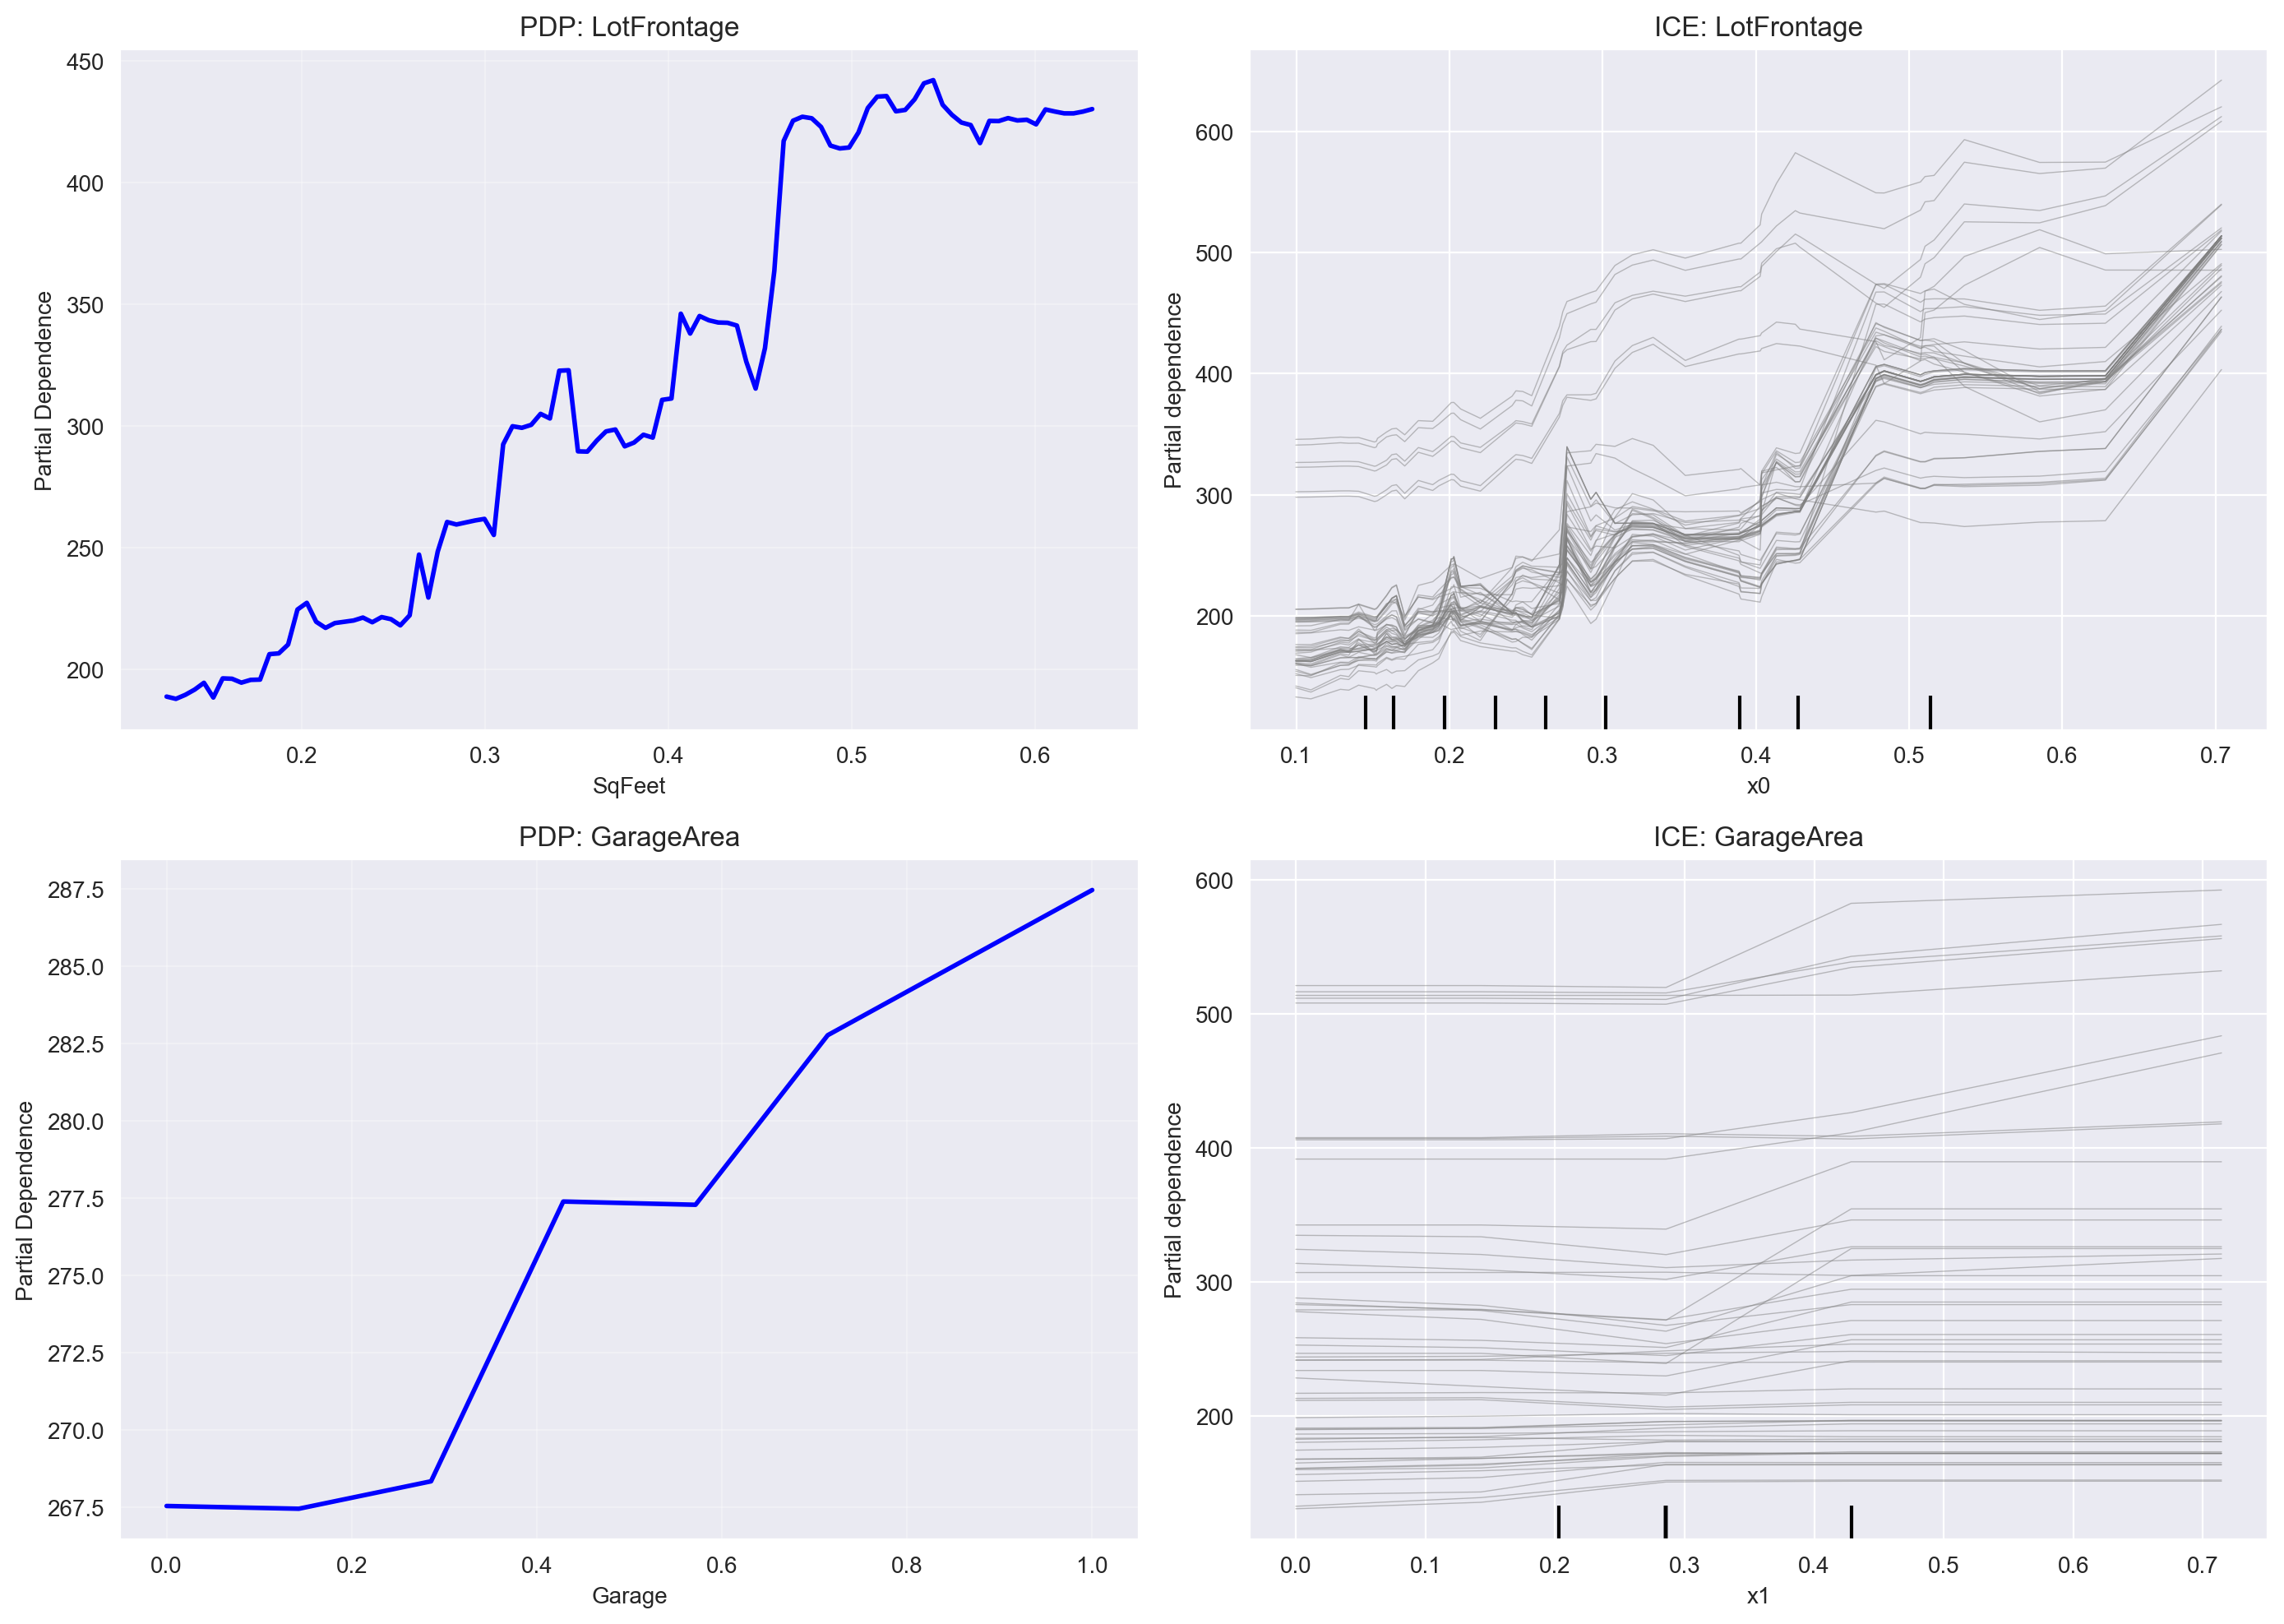

In [88]:
# без учета районов
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
plot_pdp_ice(model, X_train, features, lot_idx, 'LotFrontage', axes1[0])
plot_pdp_ice(model, X_train, features, garage_idx, 'GarageArea', axes1[1])
plt.tight_layout()
plt.show()

ValueError: The ax was already used in another plot function, please set ax=display.axes_ instead

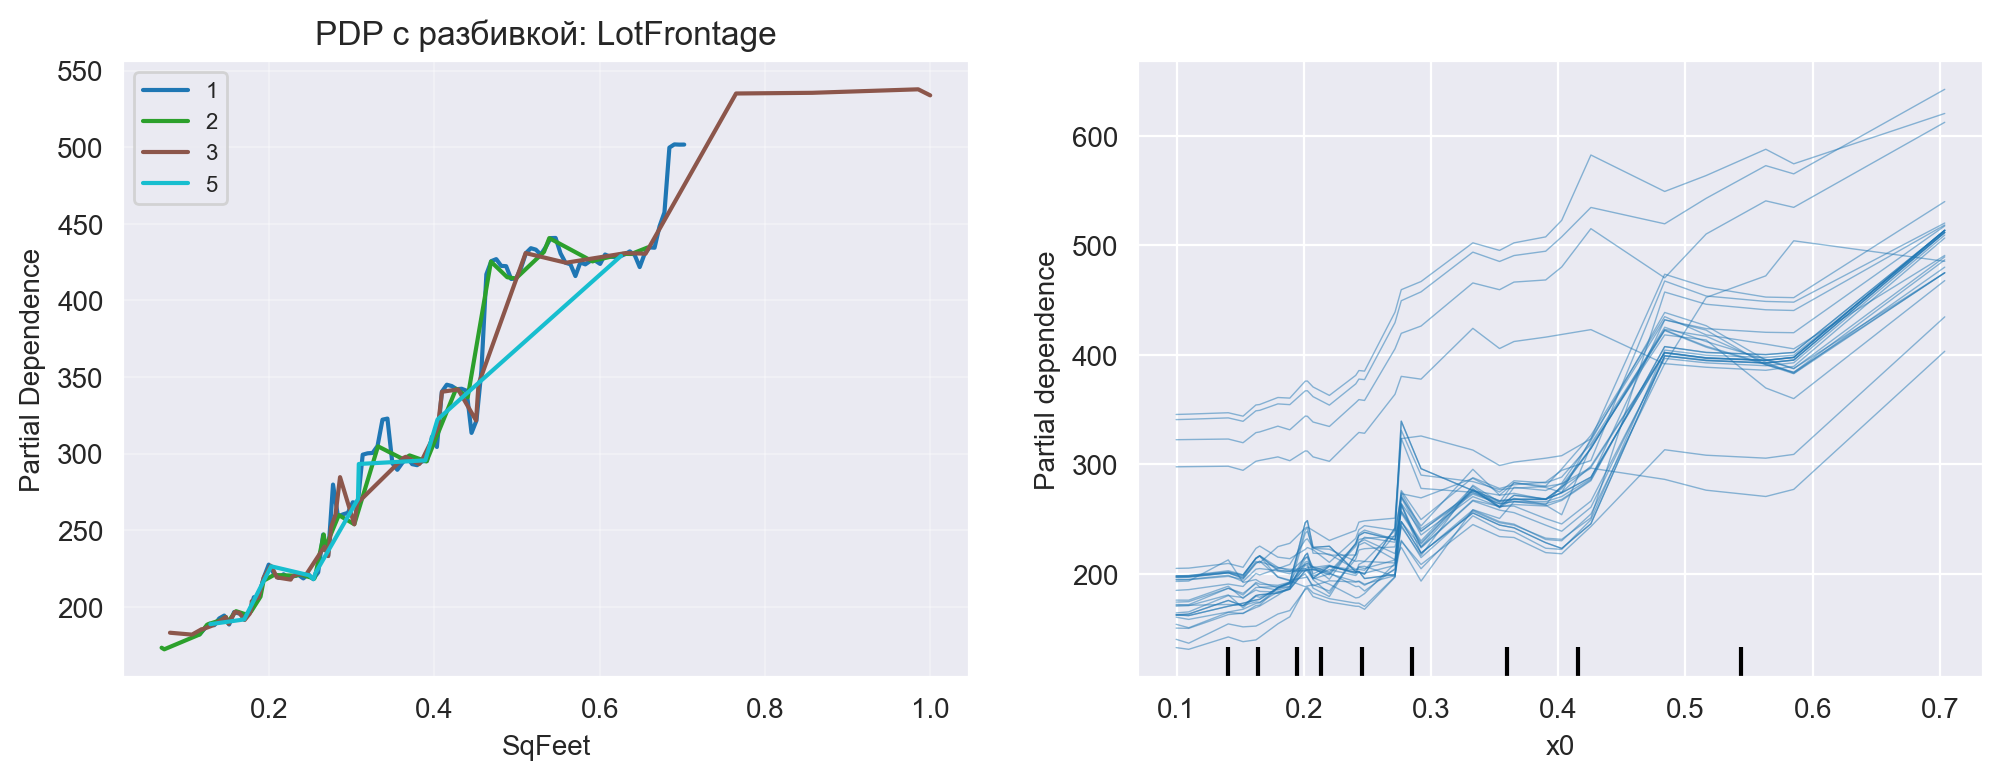

In [89]:
# с учетом районов
X_train_df = pd.DataFrame(X_train, columns=features)
X_train_df['Neighborhood'] = data.loc[:len(X_train)-1, 'Style'].values

fig2 = plot_pdp_by_neighborhood(model, X_train_df, features, lot_idx, 'Neighborhood', 'LotFrontage')
plt.tight_layout()
plt.show()

fig3 = plot_pdp_by_neighborhood(model, X_train_df, features, garage_idx, 'Neighborhood', 'GarageArea')
plt.tight_layout()
plt.show()

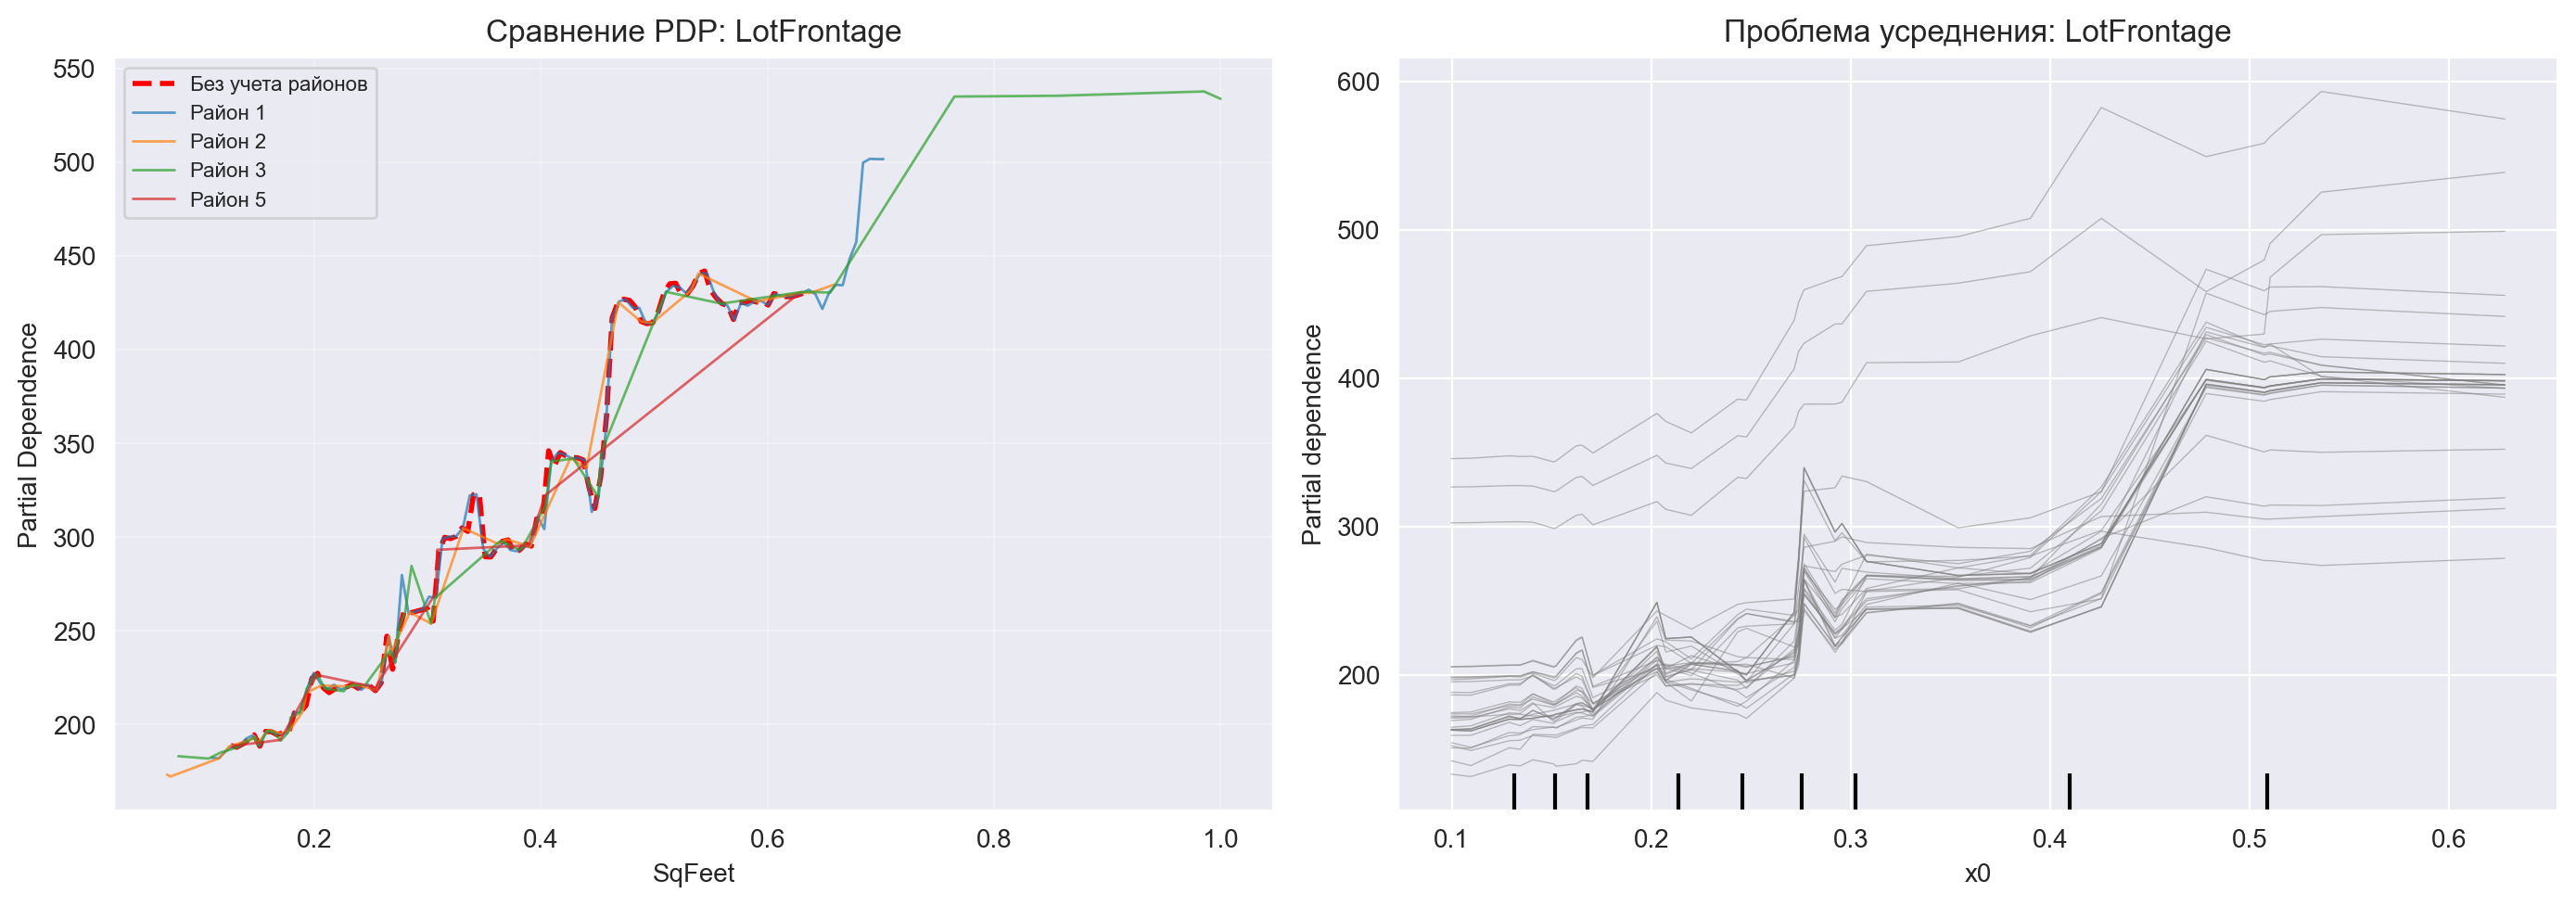

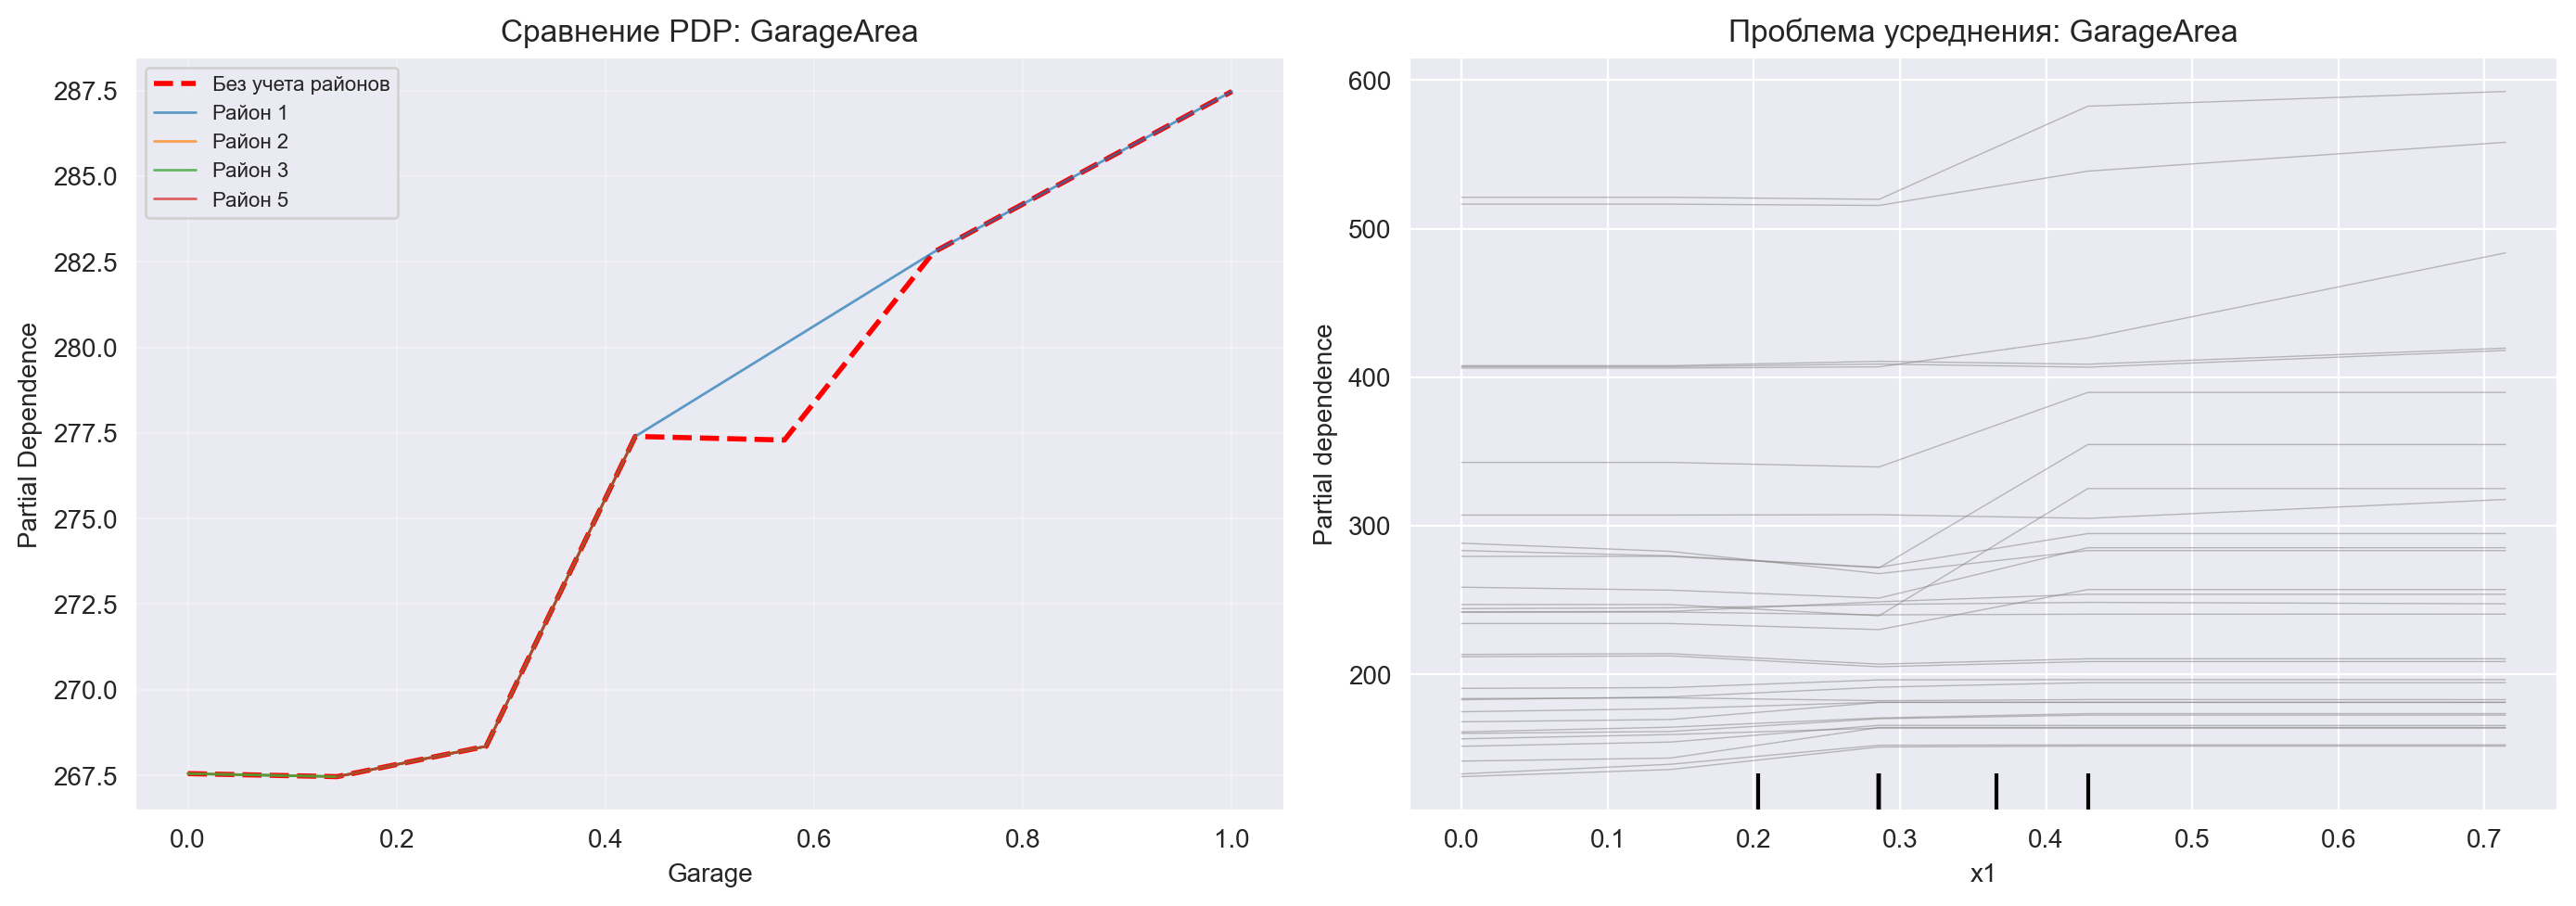

In [90]:
# сравнение и анализ проблемы усреднения
fig4 = compare_pdp(model, X_train_df, features, lot_idx, 'Neighborhood', 'LotFrontage')
plt.tight_layout()
plt.show()

fig5 = compare_pdp(model, X_train_df, features, garage_idx, 'Neighborhood', 'GarageArea')
plt.tight_layout()
plt.show()

## Accumulated Local Effects (ALE)

**Accumulated Local Effects (ALE)** решает проблему PDP с коррелированными признаками, используя условное распределение вместо маргинального.

ALE для признака $j$ определяется как:

$$ALE_j(x) = \int_{x_{min,j}}^{x} E_{X_C|X_j=z}\left[\frac{\partial f}{\partial X_j}(z, X_C)\right] dz$$

где:
- $x_{min,j}$ - минимальное значение признака $j$
- $\frac{\partial f}{\partial X_j}$ - частная производная функции модели по признаку $j$
- Усреднение происходит по условному распределению $P(X_C | X_j = z)$

**Дискретные формулы для вычисления ALE:**

В дискретном виде алгоритм вычисления ALE выглядит следующим образом:

1. **Локальный эффект для интервала $k$**:
   $$\Delta_k = \frac{1}{N_k} \sum_{i: x_{i,j} \in [z_{k-1}, z_k]} [f(z_k, x_{C,i}) - f(z_{k-1}, x_{C,i})]$$
   
   где $N_k$ - количество объектов в интервале $[z_{k-1}, z_k]$, $x_{C,i}$ - значения остальных признаков для объекта $i$.

2. **Накопленный эффект**:
   $$ALE_k = \sum_{j=1}^{k} \Delta_j$$

3. **Центрированный ALE по среднему**:
   $$ALE_k^{centered} = ALE_k - \bar{ALE}$$
   
   где $\bar{ALE} = \frac{1}{K} \sum_{k=1}^{K} ALE_k$ - среднее значение ALE по всем интервалам.

**Алгоритм вычисления ALE:**

1. **Разбиение на интервалы**: Разделить диапазон признака $j$ на $K$ интервалов
2. **Вычисление локальных эффектов**: Для каждого интервала $[z_{k-1}, z_k]$:
   - Найти объекты, у которых значение признака $j$ попадает в интервал
   - Вычислить разницу предсказаний при изменении признака от $z_{k-1}$ до $z_k$
   - Усреднить по объектам в интервале
3. **Накопление**: Проинтегрировать (суммировать) локальные эффекты от начала диапазона
4. **Центрирование**: Вычесть среднее значение ALE из всех точек, чтобы среднее значение центрированного ALE было равно нулю. Это облегчает интерпретацию и сравнение эффектов разных признаков.

In [10]:
def compute_ale(model, X: np.ndarray, feature_idx: int, n_bins: int = 50, n_samples: int = 1000, centered: bool = True) -> tuple[np.ndarray, np.ndarray]:
    feature_values = X[:, feature_idx]
    min_val = feature_values.min()
    max_val = feature_values.max()
    
    quantiles = np.linspace(0, 100, n_bins + 1)
    bin_edges = np.percentile(feature_values, quantiles)
    bin_edges[0] = min_val
    bin_edges[-1] = max_val
    
    ale_values = np.zeros(n_bins)
    ale_grid = np.zeros(n_bins)
    
    X_sample = X[np.random.choice(X.shape[0], min(n_samples, X.shape[0]), replace=False)]
    
    for k in range(n_bins):
        z_low = bin_edges[k]
        z_high = bin_edges[k + 1]
        ale_grid[k] = (z_low + z_high) / 2
        
        mask = (feature_values >= z_low) & (feature_values < z_high)
        if k == n_bins - 1:
            mask = (feature_values >= z_low) & (feature_values <= z_high)
        
        if mask.sum() == 0:
            continue
        
        X_low = X_sample.copy()
        X_high = X_sample.copy()
        X_low[:, feature_idx] = z_low
        X_high[:, feature_idx] = z_high
        
        pred_low = model.predict_proba(X_low)[:, 1]
        pred_high = model.predict_proba(X_high)[:, 1]
        
        local_effect = np.mean(pred_high - pred_low)
        ale_values[k] = local_effect
    
    ale_accumulated = np.cumsum(ale_values)
    
    if centered:
        ale_accumulated = ale_accumulated - np.mean(ale_accumulated)
    
    return ale_grid, ale_accumulated


In [11]:
ale_alpha_grid, ale_alpha_values = compute_ale(rf, X_train, feature_idx_alpha, n_bins=50)
ale_length_grid, ale_length_values = compute_ale(rf, X_train, feature_idx_length, n_bins=50)
ale_width_grid, ale_width_values = compute_ale(rf, X_train, feature_idx_width, n_bins=50)


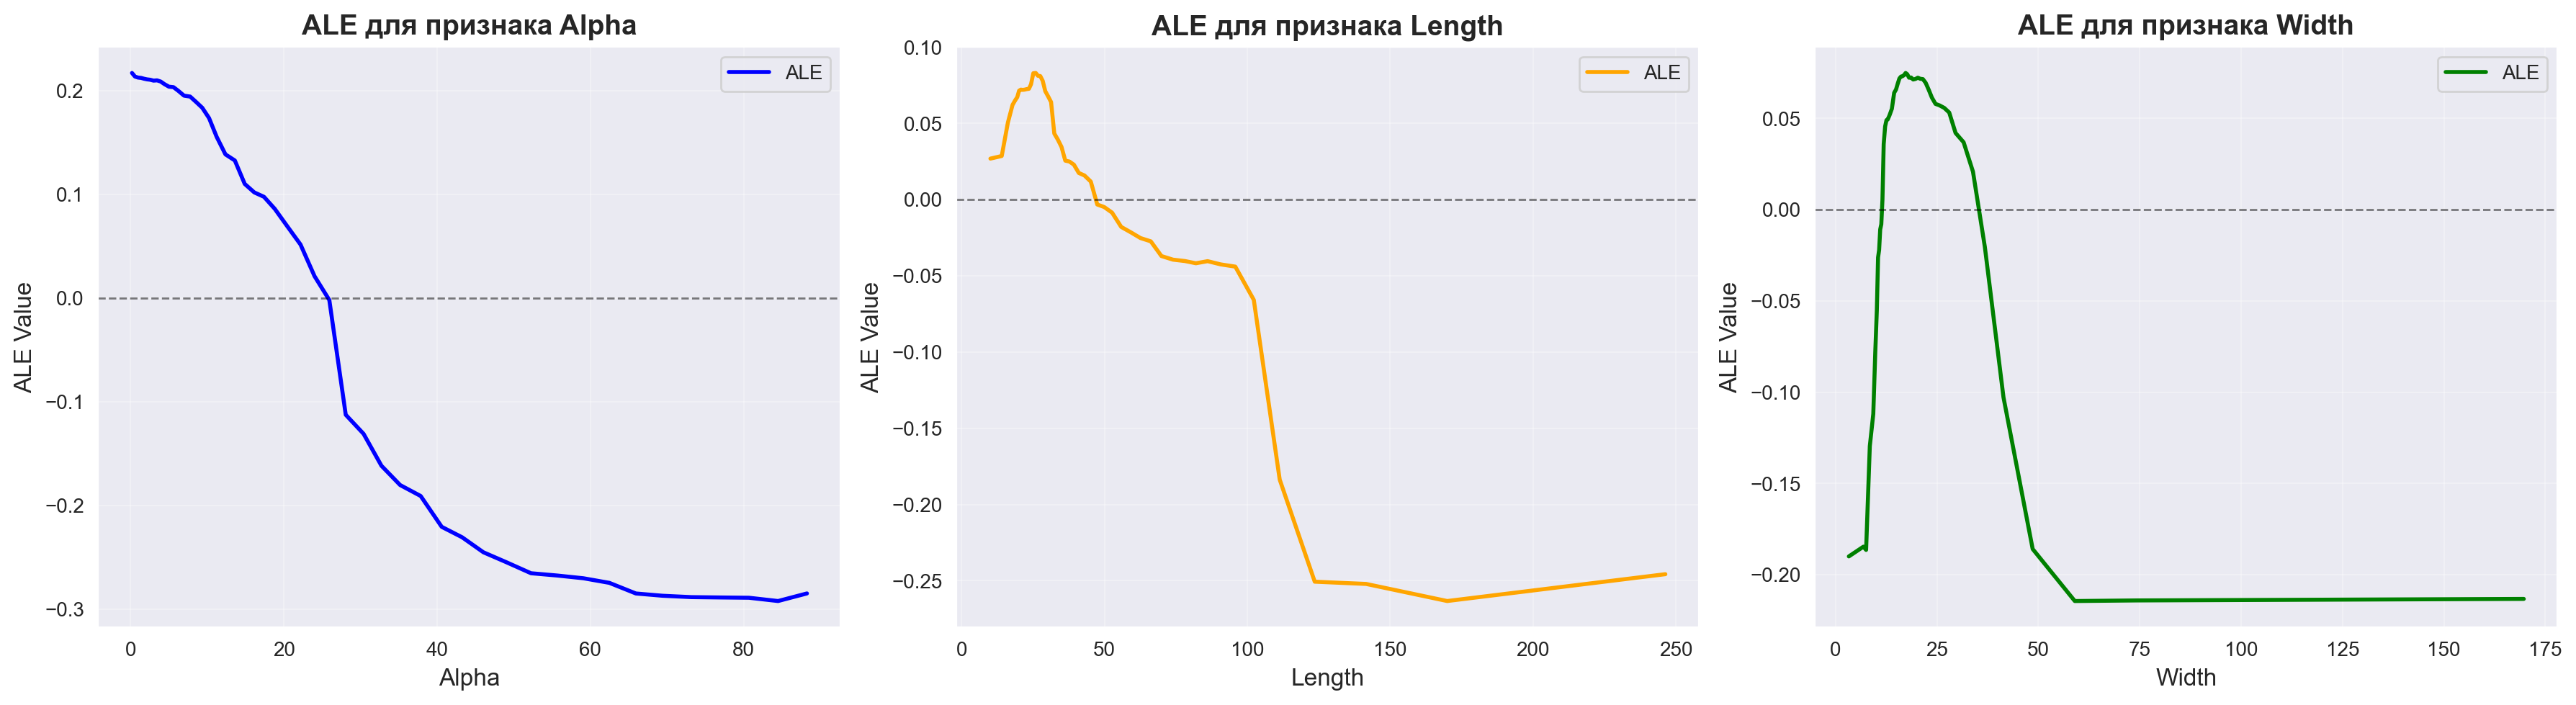

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(ale_alpha_grid, ale_alpha_values, linewidth=2, color='blue', label='ALE')
axes[0].set_xlabel('Alpha', fontsize=12)
axes[0].set_ylabel('ALE Value', fontsize=12)
axes[0].set_title('ALE для признака Alpha', fontsize=14, fontweight='bold')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(ale_length_grid, ale_length_values, linewidth=2, color='orange', label='ALE')
axes[1].set_xlabel('Length', fontsize=12)
axes[1].set_ylabel('ALE Value', fontsize=12)
axes[1].set_title('ALE для признака Length', fontsize=14, fontweight='bold')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(ale_width_grid, ale_width_values, linewidth=2, color='green', label='ALE')
axes[2].set_xlabel('Width', fontsize=12)
axes[2].set_ylabel('ALE Value', fontsize=12)
axes[2].set_title('ALE для признака Width', fontsize=14, fontweight='bold')
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


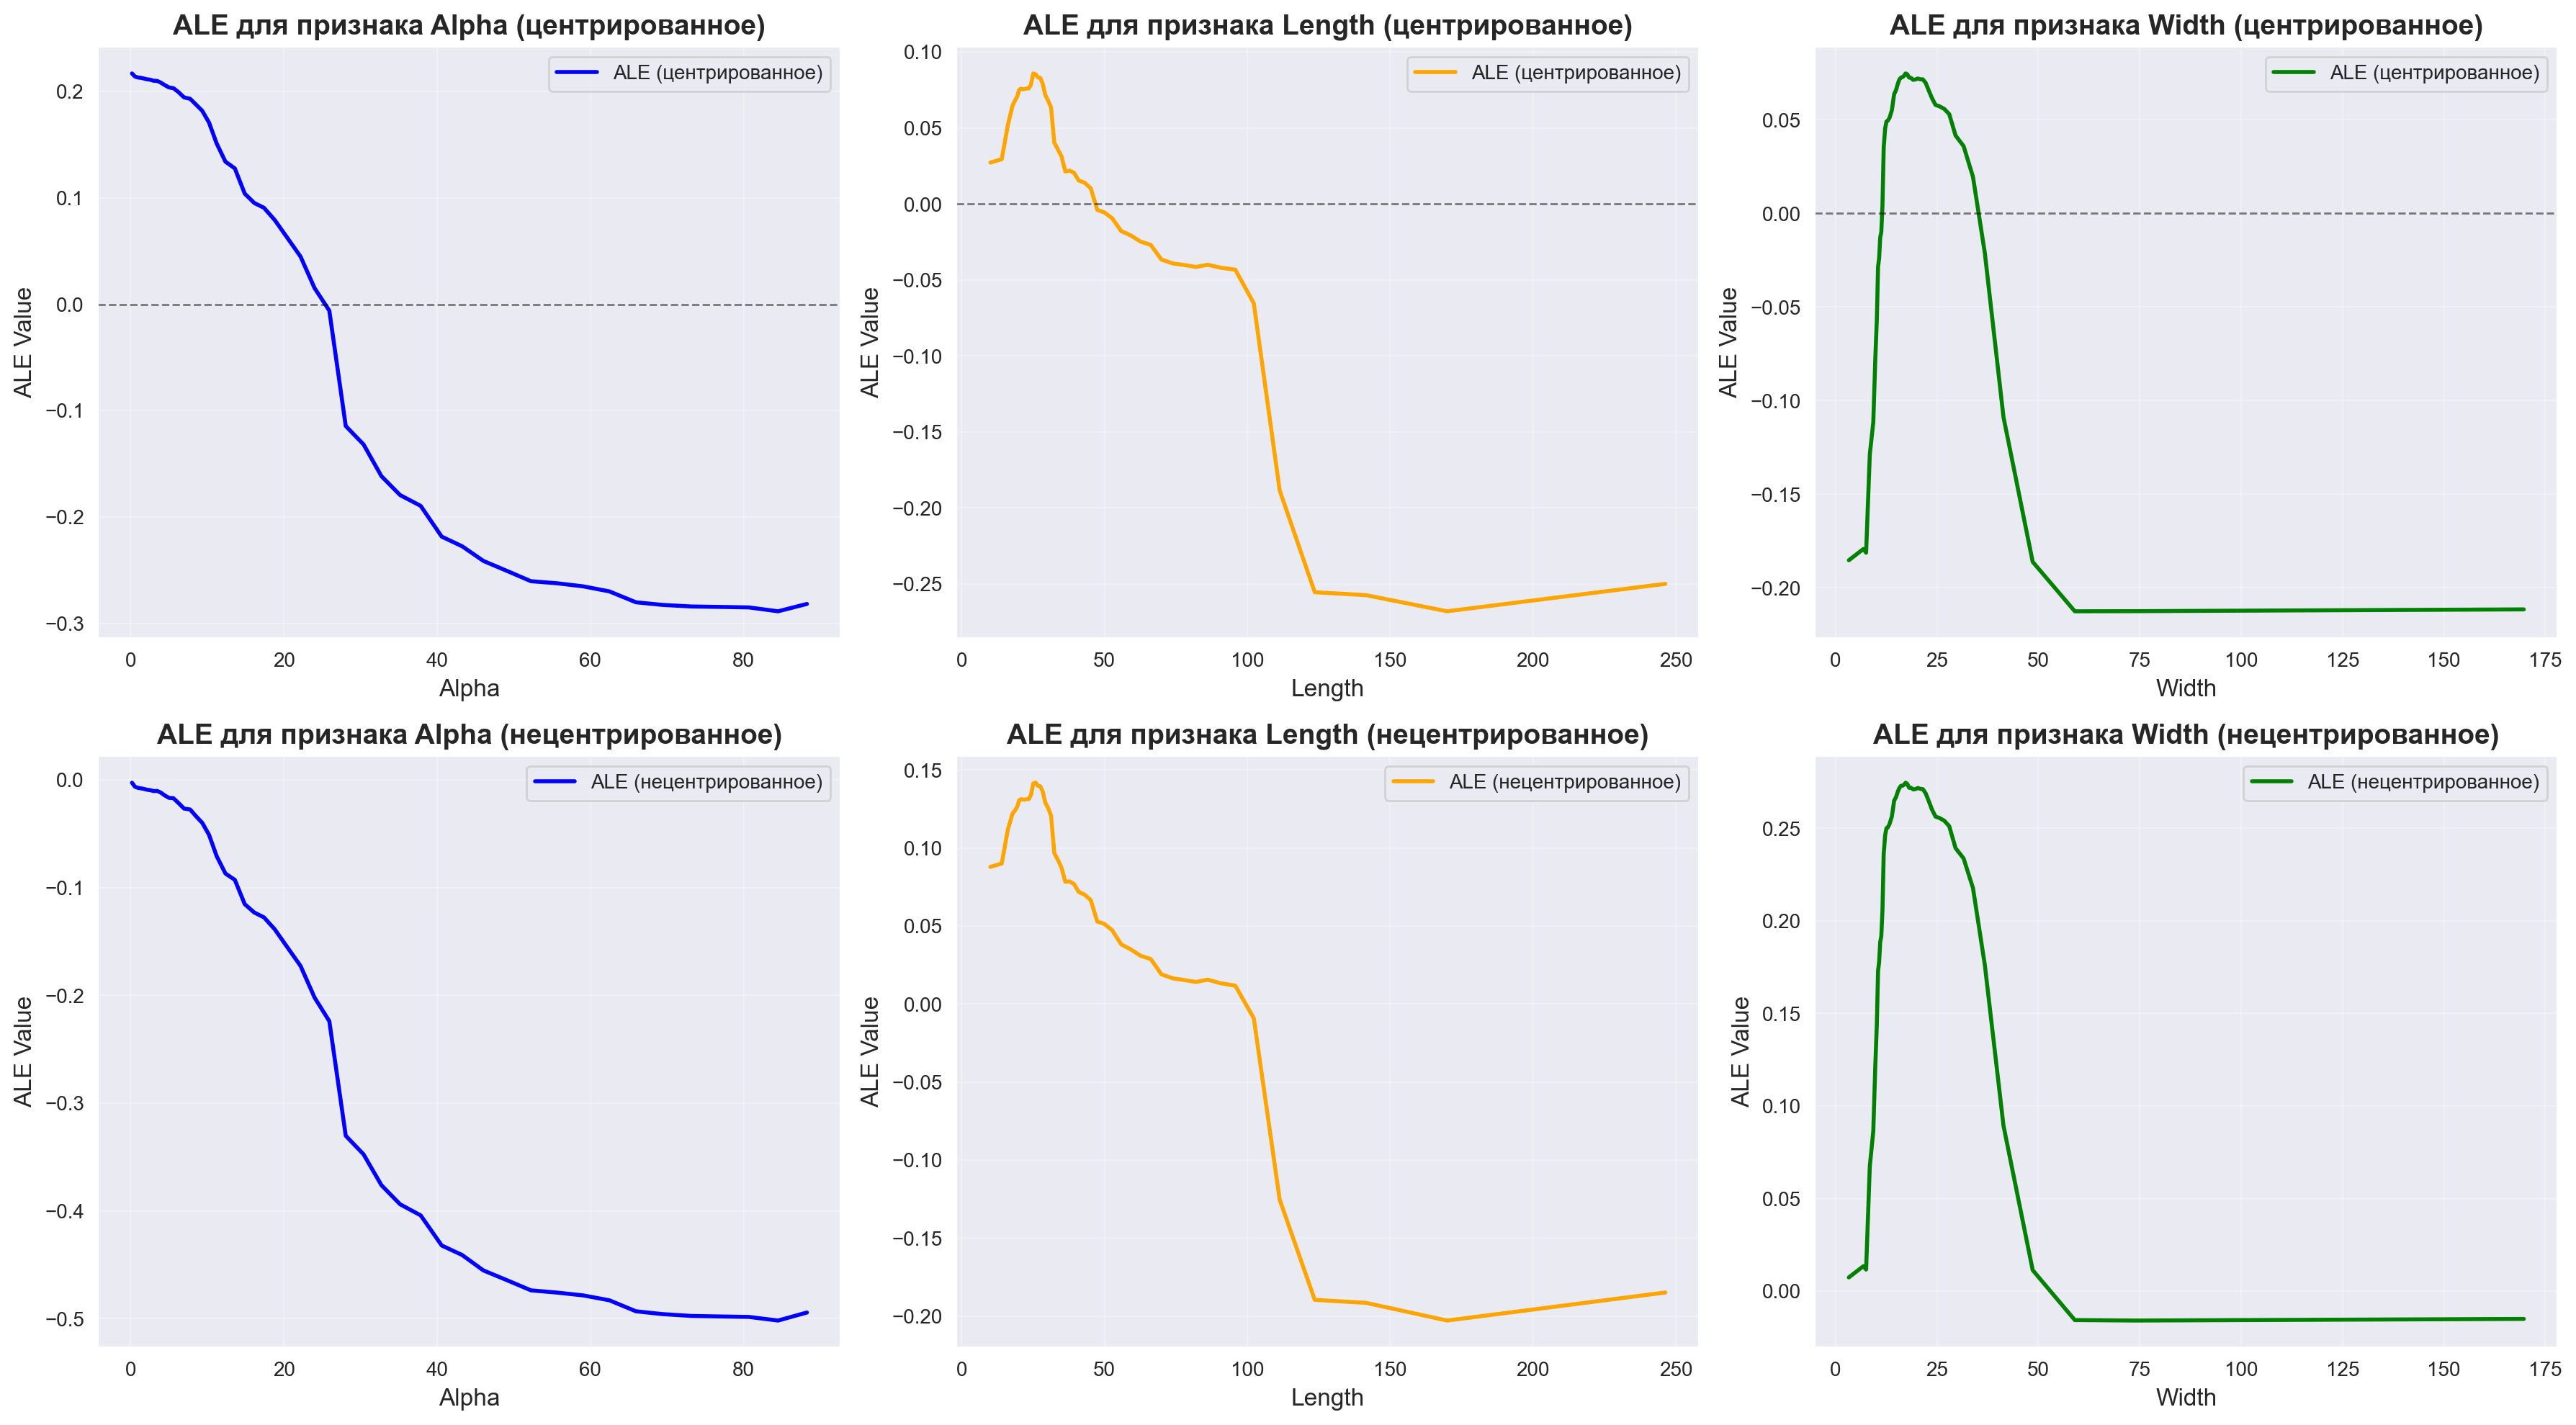

In [13]:
ale_alpha_grid_centered, ale_alpha_values_centered = compute_ale(rf, X_train, feature_idx_alpha, n_bins=50, centered=True)
ale_length_grid_centered, ale_length_values_centered = compute_ale(rf, X_train, feature_idx_length, n_bins=50, centered=True)
ale_width_grid_centered, ale_width_values_centered = compute_ale(rf, X_train, feature_idx_width, n_bins=50, centered=True)

ale_alpha_grid_uncentered, ale_alpha_values_uncentered = compute_ale(rf, X_train, feature_idx_alpha, n_bins=50, centered=False)
ale_length_grid_uncentered, ale_length_values_uncentered = compute_ale(rf, X_train, feature_idx_length, n_bins=50, centered=False)
ale_width_grid_uncentered, ale_width_values_uncentered = compute_ale(rf, X_train, feature_idx_width, n_bins=50, centered=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].plot(ale_alpha_grid_centered, ale_alpha_values_centered, linewidth=2, color='blue', label='ALE (центрированное)')
axes[0, 0].set_xlabel('Alpha', fontsize=12)
axes[0, 0].set_ylabel('ALE Value', fontsize=12)
axes[0, 0].set_title('ALE для признака Alpha (центрированное)', fontsize=14, fontweight='bold')
axes[0, 0].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(ale_length_grid_centered, ale_length_values_centered, linewidth=2, color='orange', label='ALE (центрированное)')
axes[0, 1].set_xlabel('Length', fontsize=12)
axes[0, 1].set_ylabel('ALE Value', fontsize=12)
axes[0, 1].set_title('ALE для признака Length (центрированное)', fontsize=14, fontweight='bold')
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[0, 2].plot(ale_width_grid_centered, ale_width_values_centered, linewidth=2, color='green', label='ALE (центрированное)')
axes[0, 2].set_xlabel('Width', fontsize=12)
axes[0, 2].set_ylabel('ALE Value', fontsize=12)
axes[0, 2].set_title('ALE для признака Width (центрированное)', fontsize=14, fontweight='bold')
axes[0, 2].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].legend()

axes[1, 0].plot(ale_alpha_grid_uncentered, ale_alpha_values_uncentered, linewidth=2, color='blue', label='ALE (нецентрированное)')
axes[1, 0].set_xlabel('Alpha', fontsize=12)
axes[1, 0].set_ylabel('ALE Value', fontsize=12)
axes[1, 0].set_title('ALE для признака Alpha (нецентрированное)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(ale_length_grid_uncentered, ale_length_values_uncentered, linewidth=2, color='orange', label='ALE (нецентрированное)')
axes[1, 1].set_xlabel('Length', fontsize=12)
axes[1, 1].set_ylabel('ALE Value', fontsize=12)
axes[1, 1].set_title('ALE для признака Length (нецентрированное)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

axes[1, 2].plot(ale_width_grid_uncentered, ale_width_values_uncentered, linewidth=2, color='green', label='ALE (нецентрированное)')
axes[1, 2].set_xlabel('Width', fontsize=12)
axes[1, 2].set_ylabel('ALE Value', fontsize=12)
axes[1, 2].set_title('ALE для признака Width (нецентрированное)', fontsize=14, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend()

plt.tight_layout()
plt.show()


In [ ]:
# !pip install -qU pyALE;

PyALE._ALE_generic:INFO: Continuous feature detected.


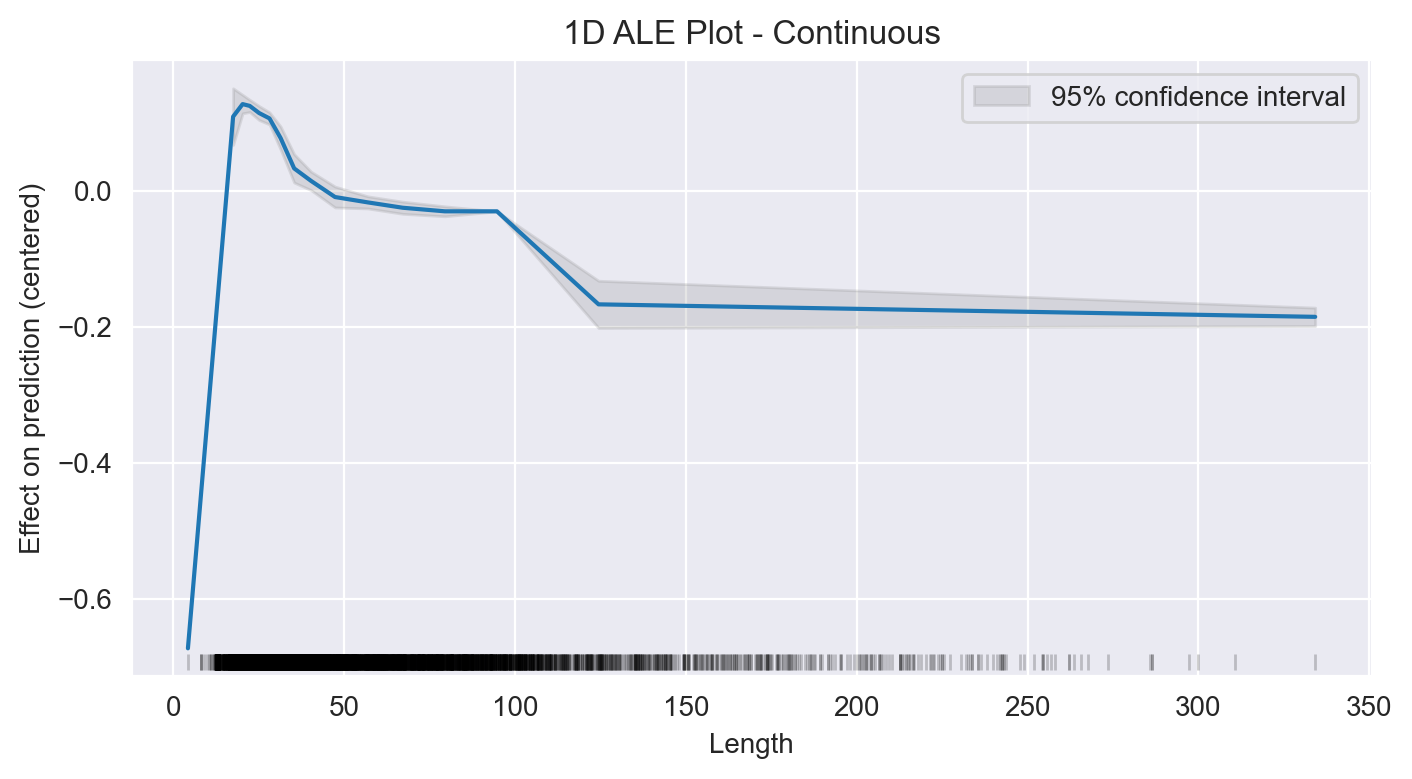

In [14]:
from PyALE import ale

## 1D - continuous - no CI
ale_eff = ale(
    X=pd.DataFrame(X_test,columns=columns), model=rf, feature=['Length'], grid_size=15,
)

PyALE._ALE_generic:INFO: Continuous feature detected.


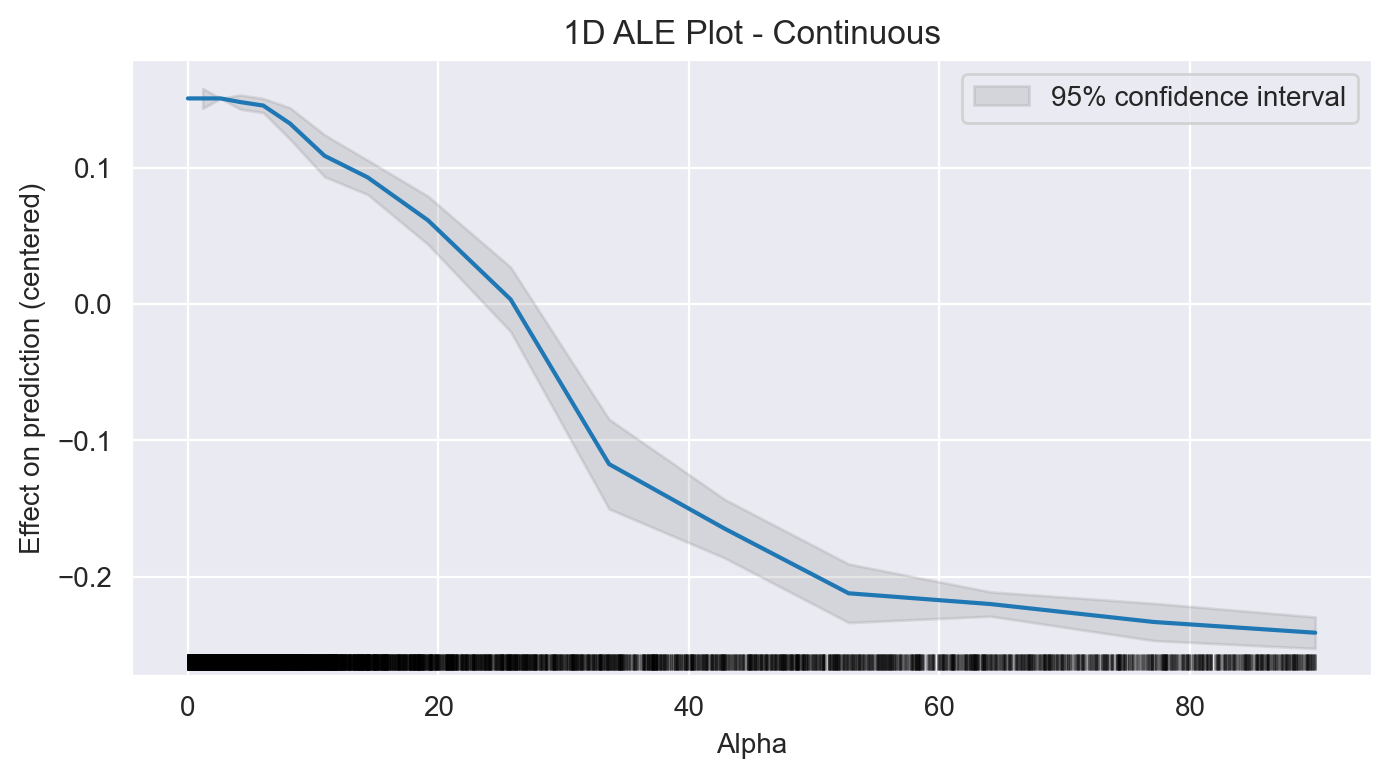

In [15]:
## 1D - continuous - no CI
ale_eff = ale(
    X=pd.DataFrame(X_test,columns=columns), model=rf, feature=['Alpha'], grid_size=15,
)

PyALE._ALE_generic:INFO: Continuous feature detected.


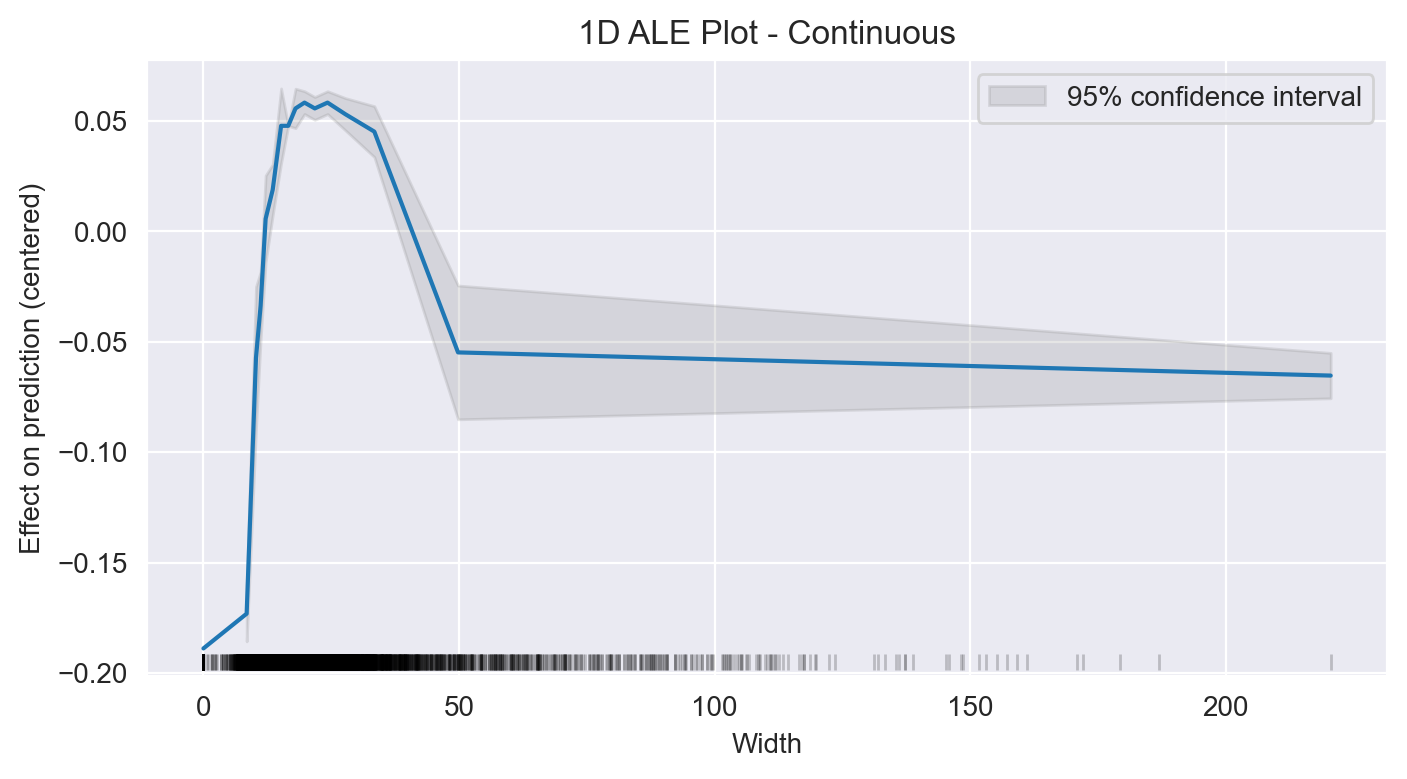

In [16]:
## 1D - continuous - no CI
ale_eff = ale(
    X=pd.DataFrame(X_test,columns=columns), model=rf, feature=['Width'], grid_size=15,
)

# LIME
Рассмотрим метод LIME (Local Interpretable Model Agnostic explanations), который позволяет построить интерпретацию для некоторого объясняемого объекта x* и его окрестности.
Для этого независимо от модели $a(x)$ для объекта вводится его объясняемое представление, и обучается модель $\hat a(x)$, которая строит предсказания для этих признаков. Чаще всего для этого используются довольно простые представления (например, мешок слов или суперпиксели). 
Для построения объясняющей модели:
1) Строится суррогатная выборка $X_{x*}^l = {(\hat x_i, y_i)}$ :
    1) создается l примеров $\hat x_i$ путем пертурбации исходных признаков, например, обнуления случайного количества единиц в интерпретируемом представлении $\hat x*$ объекта для текстов или  картинок. Вопрос, как в примере с текстом проходит обнуление?
    3) для каждого $\hat x_i$ делается переход в исходное пространство 
    4) получается $y = a(x_i)$

2) Обучается объясняющая модель:
   $$a_i = argmin_{b \in B} {\sum_{x_i} {\pi_{x*}(x_i)(a(x_i)-b((\hat x_i))^2+\sigma(b)}},$$
    - $B$ - cемейство объясняющих моделей, $\sigma(b)$ - ее сложность
    - $\pi_{x*}(x_i)$ - вес объекта, полученный с помощью некоторого ядра

Таким образом, объекты, близкие к x*, получают больший вес при обучении bб а удаленные - меньший. 

В качестве функции ошибки можно использовать и другую какую-то.
Пример - разреженные линейные представления (SLE), если использовать квадратичную функцию и $\sigma(b) = \infty[||w_b||_0 K]$ (Что за норма такая $||w_b||_0$?). Для интерпретации в таком случае достаточно вывести признаки с ненулевыми весами - так мы увидим, какие слова были использованы как самые "важные"

В итоге мы получаем довольно неплохую локальную интерпретацию, но глобально она будет, конечно же, не очень.

На практике обычно оптимизируется только часть, относящаяся к лоссу, а сложность контролируется за счет регуляризации объясняющей модели или RFE. 
Как это делается (для регуляризации): Задается большое $\lambda$, после чего оно постепенно уменьшается, пока не будет достигнуто K признаков с ненулевыми весами.

$\pi_{x*}(x_i)$ представляет собой функцию расстояния. Чаще всего используется гауссово ядро: 

$\pi_{x*}(x_i) = exp({-{d(x*, x_i)^2} \over {2\sigma^2}})$

Тут $\sigma$ - ширина ядра. Ее следует выбрать так, чтобы не размывать локальный контекст, но и не игнорировать информацию в дальних примерах.

## Таблицы

Как LIME работает с таблицами?

Во-первых, используются исходные признаки, не бинарные представления.

Во-вторых, выборки строятся путем вытягивания значения из нормального распределения со средним и стандартным отклонением, полученными из обучающего набора для каждой фичи независимо.
Кажется, что это не поможет нам строить интерпретацию для конкретного семпла. Но это работает, по крайней мере, частично. Вопрос: почему?

Для демонстрации используем уже знакомый нам датасет про дома

In [21]:
data_path = "../data/" 

In [22]:
data = pd.read_csv(pjoin(data_path, "realestate.txt"), sep="\t")
data.fillna(data.median(), inplace=True)
X = data.drop("SalePrice", axis=1)
y = data["SalePrice"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
y.mean(), y.min(), y.max(), y.std()

(np.float64(277.4126583493282),
 np.float64(84.0),
 np.float64(920.0),
 np.float64(137.61612193008258))

In [24]:
data.columns

Index(['SalePrice', 'SqFeet', 'Beds', 'Baths', 'Air', 'Garage', 'Pool', 'Year',
       'Quality', 'Style', 'Lot', 'Highway'],
      dtype='str')

In [25]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(max_depth=5).fit(X_train, y_train) # Обучите случайный лес 


In [26]:
y_pred = model.predict(X_test)

In [27]:
model.score(X_test, y_test)
root_mean_squared_error(y_pred, y_test)

67.20655546135728

In [28]:
import lime
import lime.lime_tabular

In [29]:
explainer = lime.lime_tabular.LimeTabularExplainer(X_train.values, feature_names=X_train.columns.values.tolist(),
                                                  class_names=['SalePrice'], verbose=True, mode='regression', discretize_continuous=True)

In [30]:
j = 5
exp = explainer.explain_instance(X_test.values[j], model.predict, num_features=6)

Intercept 294.39927495963707
Prediction_local [249.23555292]
Right: 186.35717947611323


In [31]:
exp.show_in_notebook(show_table=True)

ImportError: cannot import name 'display' from 'IPython.core.display' (C:\Users\2005k\PycharmProjects\spbu_ml_20261\.venv\Lib\site-packages\IPython\core\display.py)

Здесь положительное влияние показано справа, отрицательное - слева. Значения соответствуют весам линейной модели, аппроксимирующей наш случайный лес. Грубо говоря, если мы уменьшим year на 12, то и наше предсказание уменьшится на 31

Проверим, так ли

In [32]:
X_test.values[j]

array([1.7040e+00, 3.0000e+00, 2.0000e+00, 1.0000e+00, 2.0000e+00,
       0.0000e+00, 1.9840e+03, 2.0000e+00, 3.0000e+00, 2.2583e+01,
       0.0000e+00])

In [33]:
print('Original prediction:', model.predict(X_test.values[j].reshape(1, -1)))
tmp = X_test.values[j].copy()
tmp[6] = 1980

Original prediction: [186.35717948]


In [34]:
print('Prediction removing some features:',  model.predict(tmp.reshape(1, -1)))
print('Difference:', model.predict(tmp.reshape(1, -1)) - model.predict(X_test.values[j].reshape(1, -1)))

Prediction removing some features: [186.62927948]
Difference: [0.2721]


In [35]:
exp.show_in_notebook(show_table=True)

ImportError: cannot import name 'display' from 'IPython.core.display' (C:\Users\2005k\PycharmProjects\spbu_ml_20261\.venv\Lib\site-packages\IPython\core\display.py)

Интересно, что для категориальных фичей мы снова можем построить более удачные объяснения. Как мы поняли, LIME требует бинарные представления. Как мы можем к ним придти? 

In [36]:
X_train.head()

,SqFeet,Beds,Baths,Air,Garage,Pool,Year,Quality,Style,Lot,Highway
231,2.101,3,3,0,2,0,1956,2,1,65.499,0
370,1.984,5,3,1,2,0,1961,2,1,22.047,0
94,2.705,3,3,1,3,0,1994,1,1,22.196,0
209,2.414,3,3,1,2,0,1914,2,7,24.357,0
497,1.672,3,1,1,2,0,1949,3,1,22.617,0


Мы можем задать, какие фичи у нас категориальные. 

In [37]:
categorical_features = ["Beds", "Baths", "Air", "Garage", "Pool", "Quality", "Style", "Highway"]
categorical_feature_ids = [1,2,3,4,5,7,8,10]

In [38]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values, 
    feature_names=X_train.columns.values.tolist(),
    class_names=['SalePrice'], 
    categorical_features=categorical_feature_ids,
    categorical_names=categorical_features,
    verbose=True,
    mode='regression', 
    discretize_continuous=True
)
# Объясните тот же пример

Можно вообще извратиться и сделать за LIME бинаризацию. 

In [39]:
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
encoder.fit(X_train[categorical_features])
cat_df = pd.DataFrame(
    encoder.transform(X_train[categorical_features]),
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_train.index
)
X_train_ohe = pd.concat([X_train[["SqFeet","Year", "Lot"]], cat_df], axis=1)

In [40]:
X_train_ohe.head()

,SqFeet,Year,Lot,Beds_2,Beds_3,Beds_4,Beds_5,Beds_6,Beds_7,Baths_2,...,Quality_2,Quality_3,Style_2,Style_3,Style_4,Style_5,Style_6,Style_7,Style_11,Highway_1
231,2.101,1956,65.499,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
370,1.984,1961,22.047,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
94,2.705,1994,22.196,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
209,2.414,1914,24.357,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
497,1.672,1949,22.617,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
cat_df = pd.DataFrame(
    encoder.transform(X_test[categorical_features]),
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_test.index
)
X_test_ohe = pd.concat([X_test[["SqFeet","Year", "Lot"]], cat_df], axis=1)

In [42]:
encoder.get_feature_names_out()

array(['Beds_2', 'Beds_3', 'Beds_4', 'Beds_5', 'Beds_6', 'Beds_7',
       'Baths_2', 'Baths_3', 'Baths_4', 'Baths_5', 'Baths_6', 'Baths_7',
       'Air_1', 'Garage_1', 'Garage_2', 'Garage_3', 'Garage_4',
       'Garage_5', 'Garage_7', 'Pool_1', 'Quality_2', 'Quality_3',
       'Style_2', 'Style_3', 'Style_4', 'Style_5', 'Style_6', 'Style_7',
       'Style_11', 'Highway_1'], dtype=object)

In [43]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train_ohe, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [44]:
# Настройте explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_ohe.values, 
    feature_names=X_train_ohe.columns.values.tolist(),
    class_names=['SalePrice'], 
    verbose=True, 
    mode='regression', 
    discretize_continuous=True
)

In [45]:
# Постройте интерпретацию для 5 семпла (id = 4)
j = 5
exp = explainer.explain_instance(X_train_ohe.values[j], model.predict, num_features=8)

Intercept 299.9908683423488
Prediction_local [216.75072692]
Right: 170.97629999999987


In [46]:
exp.show_in_notebook(show_table=True)

ImportError: cannot import name 'display' from 'IPython.core.display' (C:\Users\2005k\PycharmProjects\spbu_ml_20261\.venv\Lib\site-packages\IPython\core\display.py)

Мы можем также задать ширину ядра и его вид.

**Задание**: Напишите свои ядра, берущие на вход расстояния и возвращающие значения от 0 до 1. Замените ядро по умолчанию. 

In [47]:
data = pd.read_csv("../data/realestate.txt", sep="\t").fillna(data.median())
X, y = data.drop("SalePrice", axis=1), data["SalePrice"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestRegressor(max_depth=5).fit(X_train, y_train)

In [48]:
def exp_kernel(d, kernel_width=0.75): return np.exp(-d/kernel_width)
def gauss_kernel(d, kernel_width=0.75): return np.exp(-0.5*(d/kernel_width)**2)
def epan_kernel(d, kernel_width=0.75): return np.maximum(0, 1 - (d/kernel_width)**2)

In [49]:
j = 5
for name, kernel in [('exp', exp_kernel), ('gauss', gauss_kernel), ('epan', epan_kernel)]:
    explainer = lime.lime_tabular.LimeTabularExplainer(
        X_train.values, feature_names=X.columns.tolist(), 
        class_names=['SalePrice'], mode='regression', kernel=kernel)
    
    exp = explainer.explain_instance(X_test.values[j], model.predict, num_features=3)
    print(f"\n{name}: {dict(exp.as_list())}")


exp: {'1.70 < SqFeet <= 2.06': -77.8493794149187, 'Quality <= 2.00': 29.553674875430513, 'Baths <= 2.00': -18.03391526862812}

gauss: {'1.70 < SqFeet <= 2.06': -76.94985806224068, 'Quality <= 2.00': 33.63324148745808, 'Baths <= 2.00': -21.260048234048327}

epan: {'1.70 < SqFeet <= 2.06': -79.00090335238423, 'Quality <= 2.00': 35.82419457784443, 'Baths <= 2.00': -24.559141922818263}


## Тексты

Также рассмотрим интерпретацию для классификации новостей на две группы - атеизм и христианство.

In [50]:
from sklearn.datasets import fetch_20newsgroups
categories = ['alt.atheism', 'soc.religion.christian']
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories)
class_names = ['atheism', 'christian']

Векторизуем тексты с помощью TF-IDF

In [51]:
vectorizer = TfidfVectorizer(lowercase=False)
train_vectors = vectorizer.fit_transform(newsgroups_train.data)
test_vectors =  vectorizer.transform(newsgroups_test.data)# сделайте то же самое и для теста

In [52]:
rf = RandomForestClassifier().fit(train_vectors, newsgroups_train.target) # Обучите случайный лес

In [53]:
pred = rf.predict(test_vectors)
f1_score(newsgroups_test.target, pred, average='binary')

0.9241540256709452

In [54]:
from sklearn.pipeline import make_pipeline
c = make_pipeline(vectorizer, rf)

In [55]:
print(c.predict_proba([newsgroups_test.data[0]]))

[[0.27 0.73]]


In [56]:
from lime.lime_text import LimeTextExplainer
explainer = LimeTextExplainer(class_names=class_names)

In [57]:
idx = 83
exp = explainer.explain_instance(newsgroups_test.data[idx], c.predict_proba, num_features=6)
print('Document id: %d' % idx)
print('Probability(christian) =', c.predict_proba([newsgroups_test.data[idx]])[0,1])
print('True class: %s' % class_names[newsgroups_test.target[idx]])

Document id: 83
Probability(christian) = 0.35
True class: atheism


In [58]:
exp.as_list()

[(np.str_('NNTP'), -0.16019351132581924),
 (np.str_('Host'), -0.15429953787852815),
 (np.str_('Posting'), -0.1348409810650763),
 (np.str_('edu'), -0.035765202938894604),
 (np.str_('unm'), -0.01770842867370579),
 (np.str_('notes'), -0.013813598951971035)]

In [59]:
exp.show_in_notebook(text=False)

ImportError: cannot import name 'display' from 'IPython.core.display' (C:\Users\2005k\PycharmProjects\spbu_ml_20261\.venv\Lib\site-packages\IPython\core\display.py)

Посмотрим, сохраняется ли ситуация с изменением фичей. Тут ожидание следующее - вероятность увеличится на 0.3, если мы уберем из текста слова Host и Posting.

In [60]:
print('Original prediction:', rf.predict_proba(test_vectors[idx])[0,1])
tmp = test_vectors[idx].copy()
tmp[0,vectorizer.vocabulary_['Posting']] = 0
tmp[0,vectorizer.vocabulary_['Host']] = 0
print('Prediction removing some features:', rf.predict_proba(tmp)[0,1])
print('Difference:', rf.predict_proba(tmp)[0,1] - rf.predict_proba(test_vectors[idx])[0,1])

Original prediction: 0.35
Prediction removing some features: 0.62
Difference: 0.27


Для текстов мы можем еще и посмотреть на самые важные слова:

In [61]:
exp.show_in_notebook(text=True)

ImportError: cannot import name 'display' from 'IPython.core.display' (C:\Users\2005k\PycharmProjects\spbu_ml_20261\.venv\Lib\site-packages\IPython\core\display.py)

Судя по всему, на самом деле моделька смотрит на мусор типа заголовков или частых слов. Проверим, так ли это для какого-то другого примера:

In [62]:
idx = 34
exp = explainer.explain_instance(newsgroups_test.data[idx], c.predict_proba, num_features=6)
print('Document id: %d' % idx)
print('Probability(christian) =', c.predict_proba([newsgroups_test.data[idx]])[0,1])
print('True class: %s' % class_names[newsgroups_test.target[idx]])
exp.show_in_notebook(text=True)

Document id: 34
Probability(christian) = 0.8
True class: christian


ImportError: cannot import name 'display' from 'IPython.core.display' (C:\Users\2005k\PycharmProjects\spbu_ml_20261\.venv\Lib\site-packages\IPython\core\display.py)

Плюсы: 
- Можно поменять предсказывающую модель, но все еще использовать ту же объясняющую
- Легко применить, работает с разными видами данных
  
Минусы:
- Для табличных данных очень сложно выбрать ядро, да и вообще выбор ядра может значительно поменять интерпретацию.
- Сложность объяснения должна быть выбрана заранее
- Нестабильный

**Задание(*):**
У вас есть все составляющие LIME - ядра, алгоритм, кодировка фичей, loess с прошлой пары. Не хватает только кода с семплированием.
Напишите свой класс Lime для регрессии и таблиц, который с помощью линейной регрессии и заданного ядра строит интерпретацию. В качестве сложности используйте способ с регуляризацией (можете LARS). При вызове он должен вернуть коэффициенты регрессии, использованные для интерпретации. Не забудьте отшкалиировать фичи. В качестве метрики используйте евклидову.
Сделайте упрощенное семплирование - только нормальное распределение и дискретное по частотности категорий.

In [63]:
class LIME:
    def __init__(self, train_df, kernel, kernel_width, categorical_features=None):
        pass

    def _generate_sample(self, instance):
        pass
        
    def explain(self, instance, prediction, num_features=5):
        pass
        

## SHAP

Значения Шепли как практический инструмент решают три проблемы сразу:
- оценка локального влияния прищнака на прогноз
- оценка глобального влияния признаков
- оценка взаимодействия признаков

За счет универсальности и согласованности, а также независимости от модели, это один из наиболее популярных методов интрепретации признаков. 

Изначально этот метод пришел из теории игр, поэтому нам нужны дополнительные определения:

1. **Коалиционная игра** - это пара $(N, v)$, где:
   - $N = \{1, 2, \ldots, M\}$ - множество игроков (в нашем случае - множество признаков)
   - $v: 2^N \rightarrow \mathbb{R}$ - характеристическая функция, которая ставит в соответствие каждой коалиции (подмножеству признаков) $S \subseteq N$ некоторое значение $v(S)$. В контексте машинного обучения это функция, которая возвращает предсказание модели при использовании только признаков из подмножества $S$:
   $$v(S) = E[f(X) | X_S = x_S]$$
   где $X_S$ - признаки из подмножества $S$, а $x_S$ - их конкретные значения для объясняемого объекта.

3. **Маргинальный вклад признака $i$** при добавлении к коалиции $S$:
   $$\Delta_i(S) = v(S \cup \{i\}) - v(S)$$
   Это разница между предсказанием модели с признаком $i$ и без него, при фиксированных значениях признаков из $S$.

**Формула значения Шепли:**

Значение Шепли для признака $i$ определяется как средневзвешенный маргинальный вклад по всем возможным коалициям:

$$\phi_i(v) = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!(M - |S| - 1)!}{M!} [v(S \cup \{i\}) - v(S)]$$

где:
- $M$ - общее количество признаков
- $S$ - подмножество признаков без признака $i$
- $|S|$ - размер подмножества $S$
- $\frac{|S|!(M - |S| - 1)!}{M!}$ - весовой коэффициент, равный вероятности того, что признак $i$ будет добавлен к случайно выбранной коалиции размера $|S|$

**Алгоритм вычисления значения Шепли:**

1. **Для каждого признака $i \in \{1, 2, \ldots, M\}$:**
   
2. **Для каждой возможной коалиции $S \subseteq N \setminus \{i\}$:**
   - Вычислить предсказание модели $v(S)$ без признака $i$ (используя только признаки из $S$)
   - Вычислить предсказание модели $v(S \cup \{i\})$ с признаком $i$ (используя признаки из $S$ и признак $i$)
   - Вычислить маргинальный вклад: $\Delta_i(S) = v(S \cup \{i\}) - v(S)$
   - Вычислить вес коалиции: $w(S) = \frac{|S|!(M - |S| - 1)!}{M!}$

3. **Усреднить маргинальные вклады с весами:**
   $$\phi_i = \sum_{S \subseteq N \setminus \{i\}} w(S) \cdot \Delta_i(S)$$


**Свойства значений Шепли (аксиомы):**

1. **Эффективность (Efficiency)**: $\sum_{i=1}^{M} \phi_i = v(N) - v(\emptyset)$
   - Сумма всех значений Шепли равна разнице между предсказанием со всеми признаками и предсказанием без признаков

2. **Симметрия (Symmetry)**: Если $v(S \cup \{i\}) = v(S \cup \{j\})$ для всех $S$, то $\phi_i = \phi_j$
   - Признаки с одинаковым влиянием получают одинаковые значения

3. **Фиктивность (Dummy)**: Если $v(S \cup \{i\}) = v(S)$ для всех $S$, то $\phi_i = 0$
   - Признак, не влияющий на предсказание, получает нулевое значение

4. **Аддитивность (Additivity)**: Для двух игр $v$ и $w$: $\phi_i(v + w) = \phi_i(v) + \phi_i(w)$
   - Значения Шепли аддитивны относительно комбинации игр



In [64]:
import shap
#Локальное объяснение с shap

shap.initjs()
explainer = shap.TreeExplainer(model, feature_names=X_test_ohe.columns)
shap_values = explainer(X_test_ohe)

X_train_sc_df = pd.DataFrame(X_test_ohe, columns=X_test_ohe.columns)


Force Plot показывает локальное объяснение предсказания модели для одного объекта. На этом графике:
- Базовое значение (base value) - среднее предсказание модели на обучающей выборке.
- Ширина полосы отображает вклад.
- Финальное предсказание (output value) - результат суммирования базового значения и всех вкладов:
   $$f(x) = \text{base\_value} + \sum_{i=1}^{M} \phi_i$$
Признаки обычно отсортированы по величине вклада (по убыванию абсолютного значения).Вклад считается только для конкртеного семпла иотличается от глобальной важности (и можеет даже не совпадать по порядку с общей важностью)

Для классификации можно использовать аргумент link="logit", чтобы выводить логиты. Кроме того, для классификации удобно использовать другой стиль для неправильно отклассифицированных семплов (например через  highlight=misclassified)

In [65]:
# Визуализируем прогнозы для 5-го объекта в тестовых данных
shap.plots.force(shap_values[5, :])

Decision Plot показывает, как модель "принимает решение" для одного или нескольких объектов, показывая путь от базового значения к финальному предсказанию.
Ось Y - список признаков, отсортированных по важности (сверху вниз - от самых важных к менее важным)
Ось X - значения предсказания модели (обычно в шкале исходной задачи - например, цена дома или вероятность класса)
Каждая линия представляет один объект:
   - Линия начинается слева от базового значения (expected value)
   - Проходит через все признаки, накапливая их вклады
   - Заканчивается справа на финальном предсказании для этого объекта


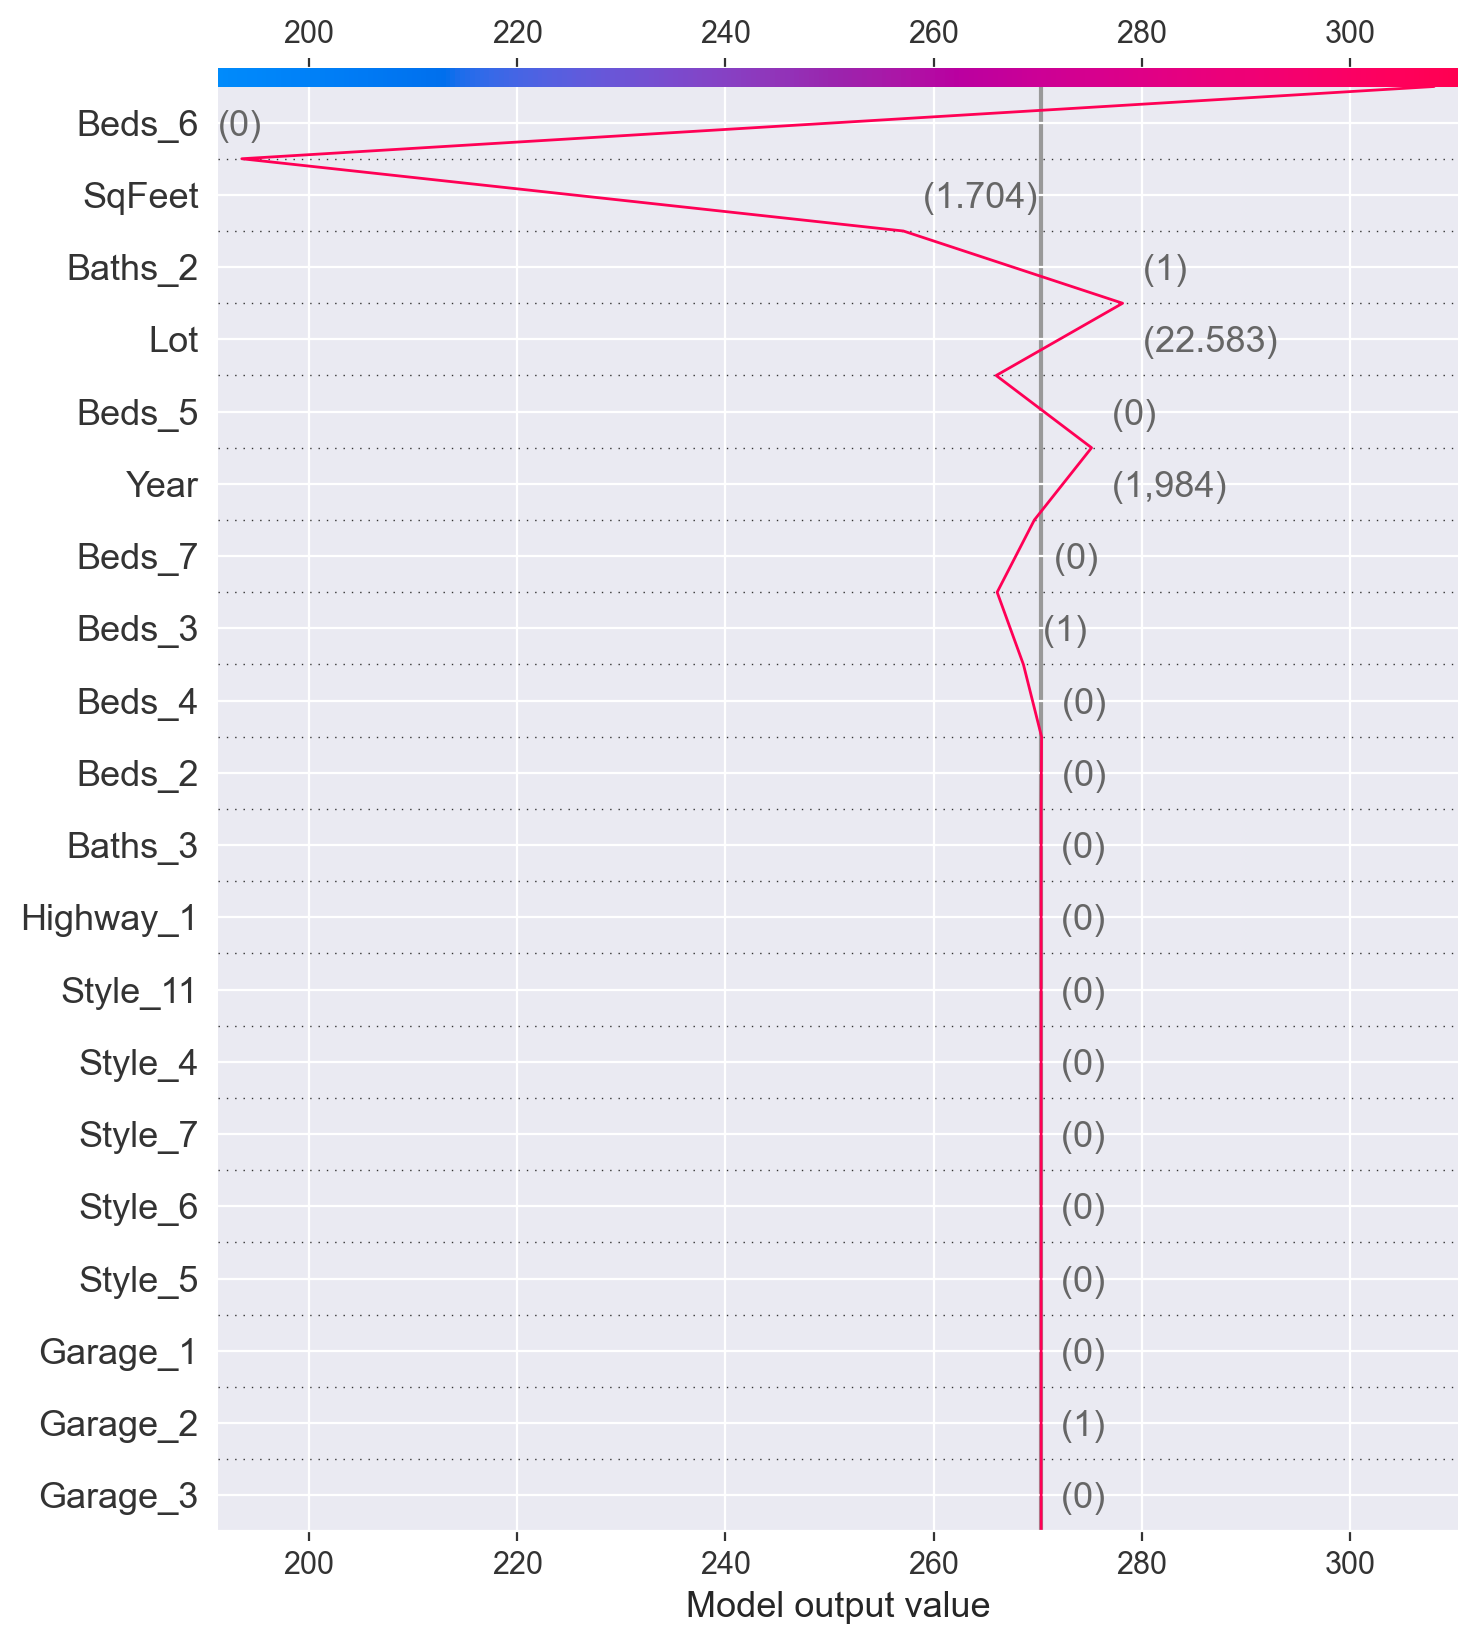

In [66]:
shap.decision_plot(
    explainer.expected_value, 
    explainer.shap_values(X_test_ohe[5:6]), 
    X_test_ohe[5:6]
)

Decision plot бывает удобнее force plot, например, когда число фичей велико и хочется явно увидеть их вклады. Кроме того, этот график поддерживает несколько выходов модели или позволяет сравнить несколько моделей.

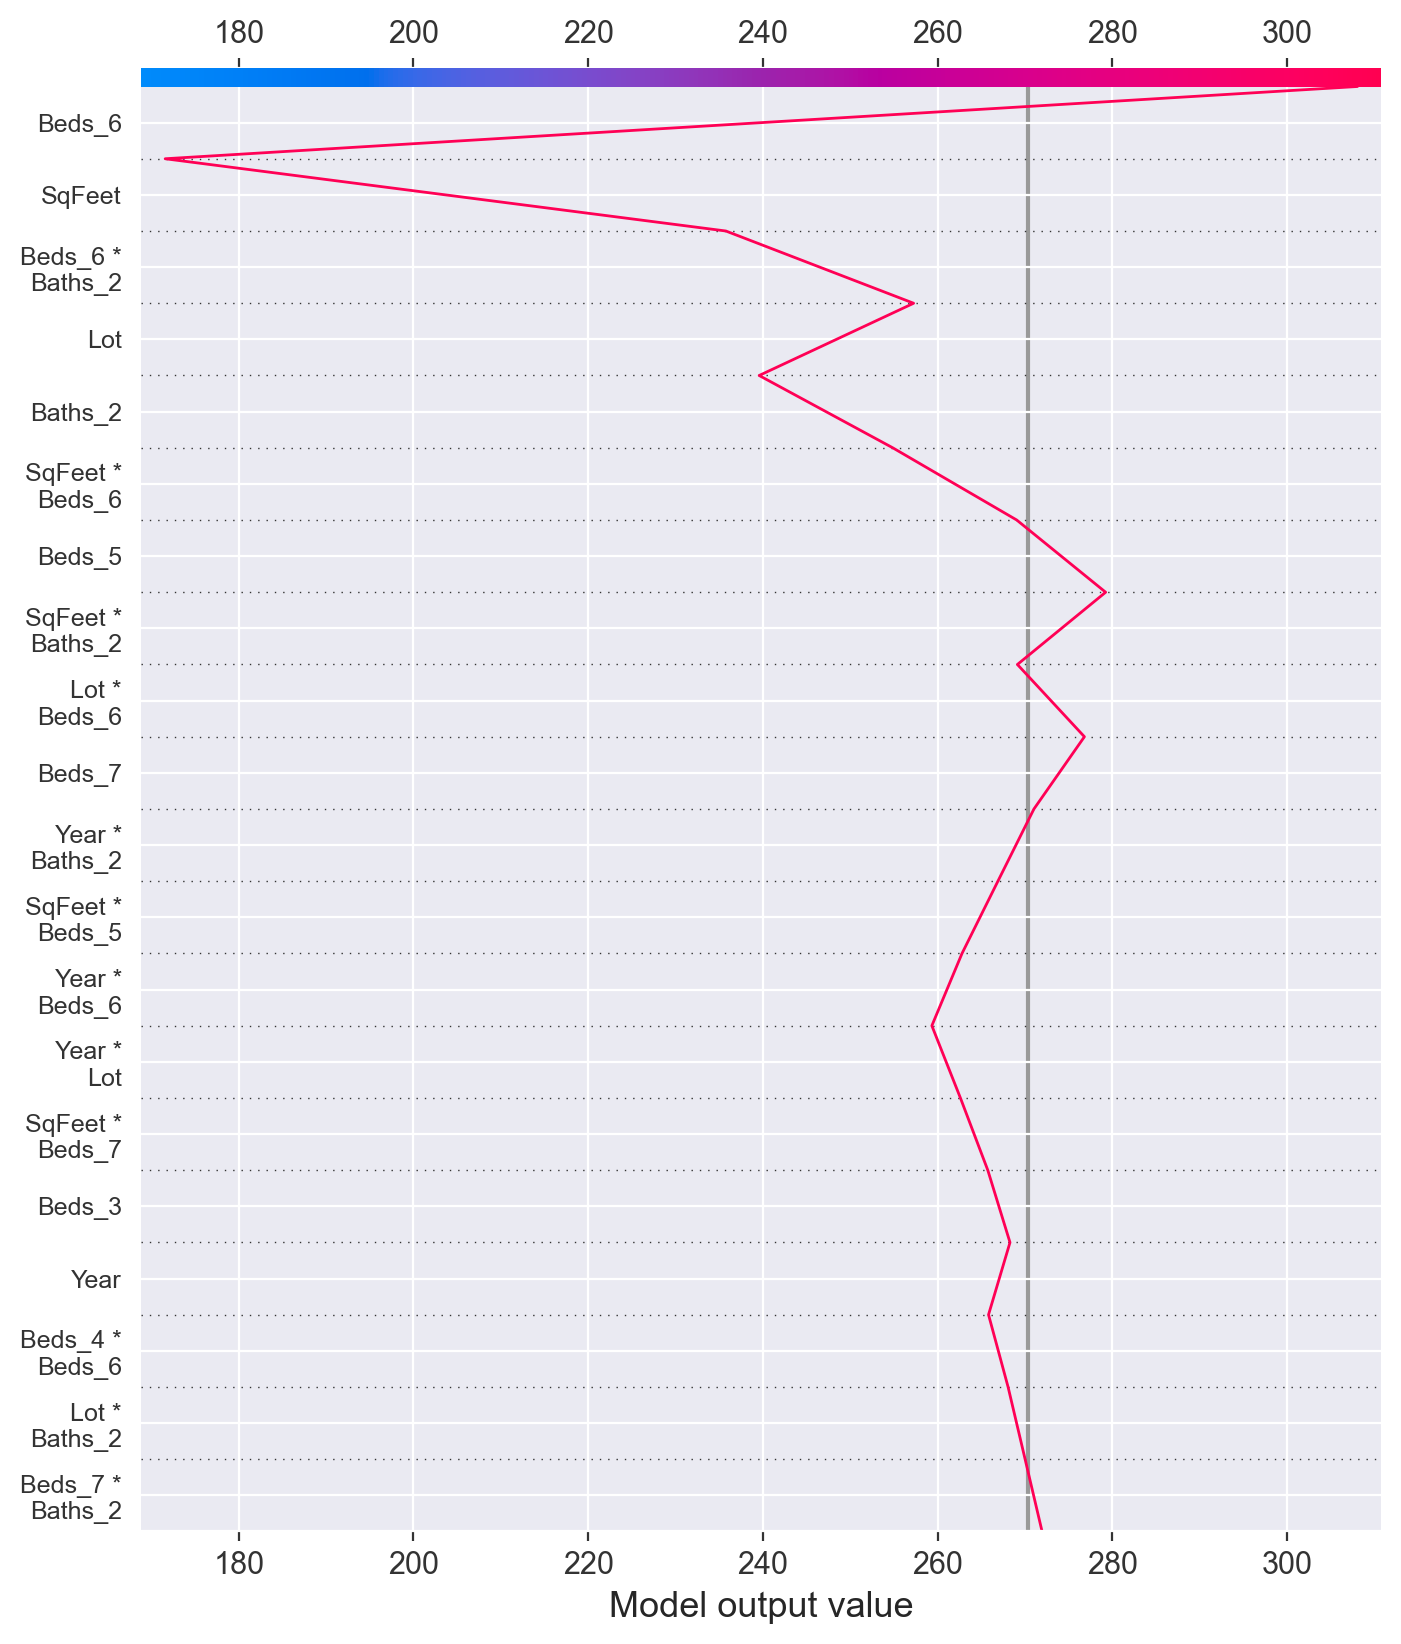

In [67]:
shap_interaction_values = explainer.shap_interaction_values(X_test_ohe[5:6])
shap.decision_plot(
    explainer.expected_value,
    shap_interaction_values,
    X_test_ohe[5:6]
)

С помощью этого графика можно также находить выбросы (если линии сильно отклоняются от стандартных), оценить гипотетические сценарии (что будет, если площадь дома изменится на 100 метров)

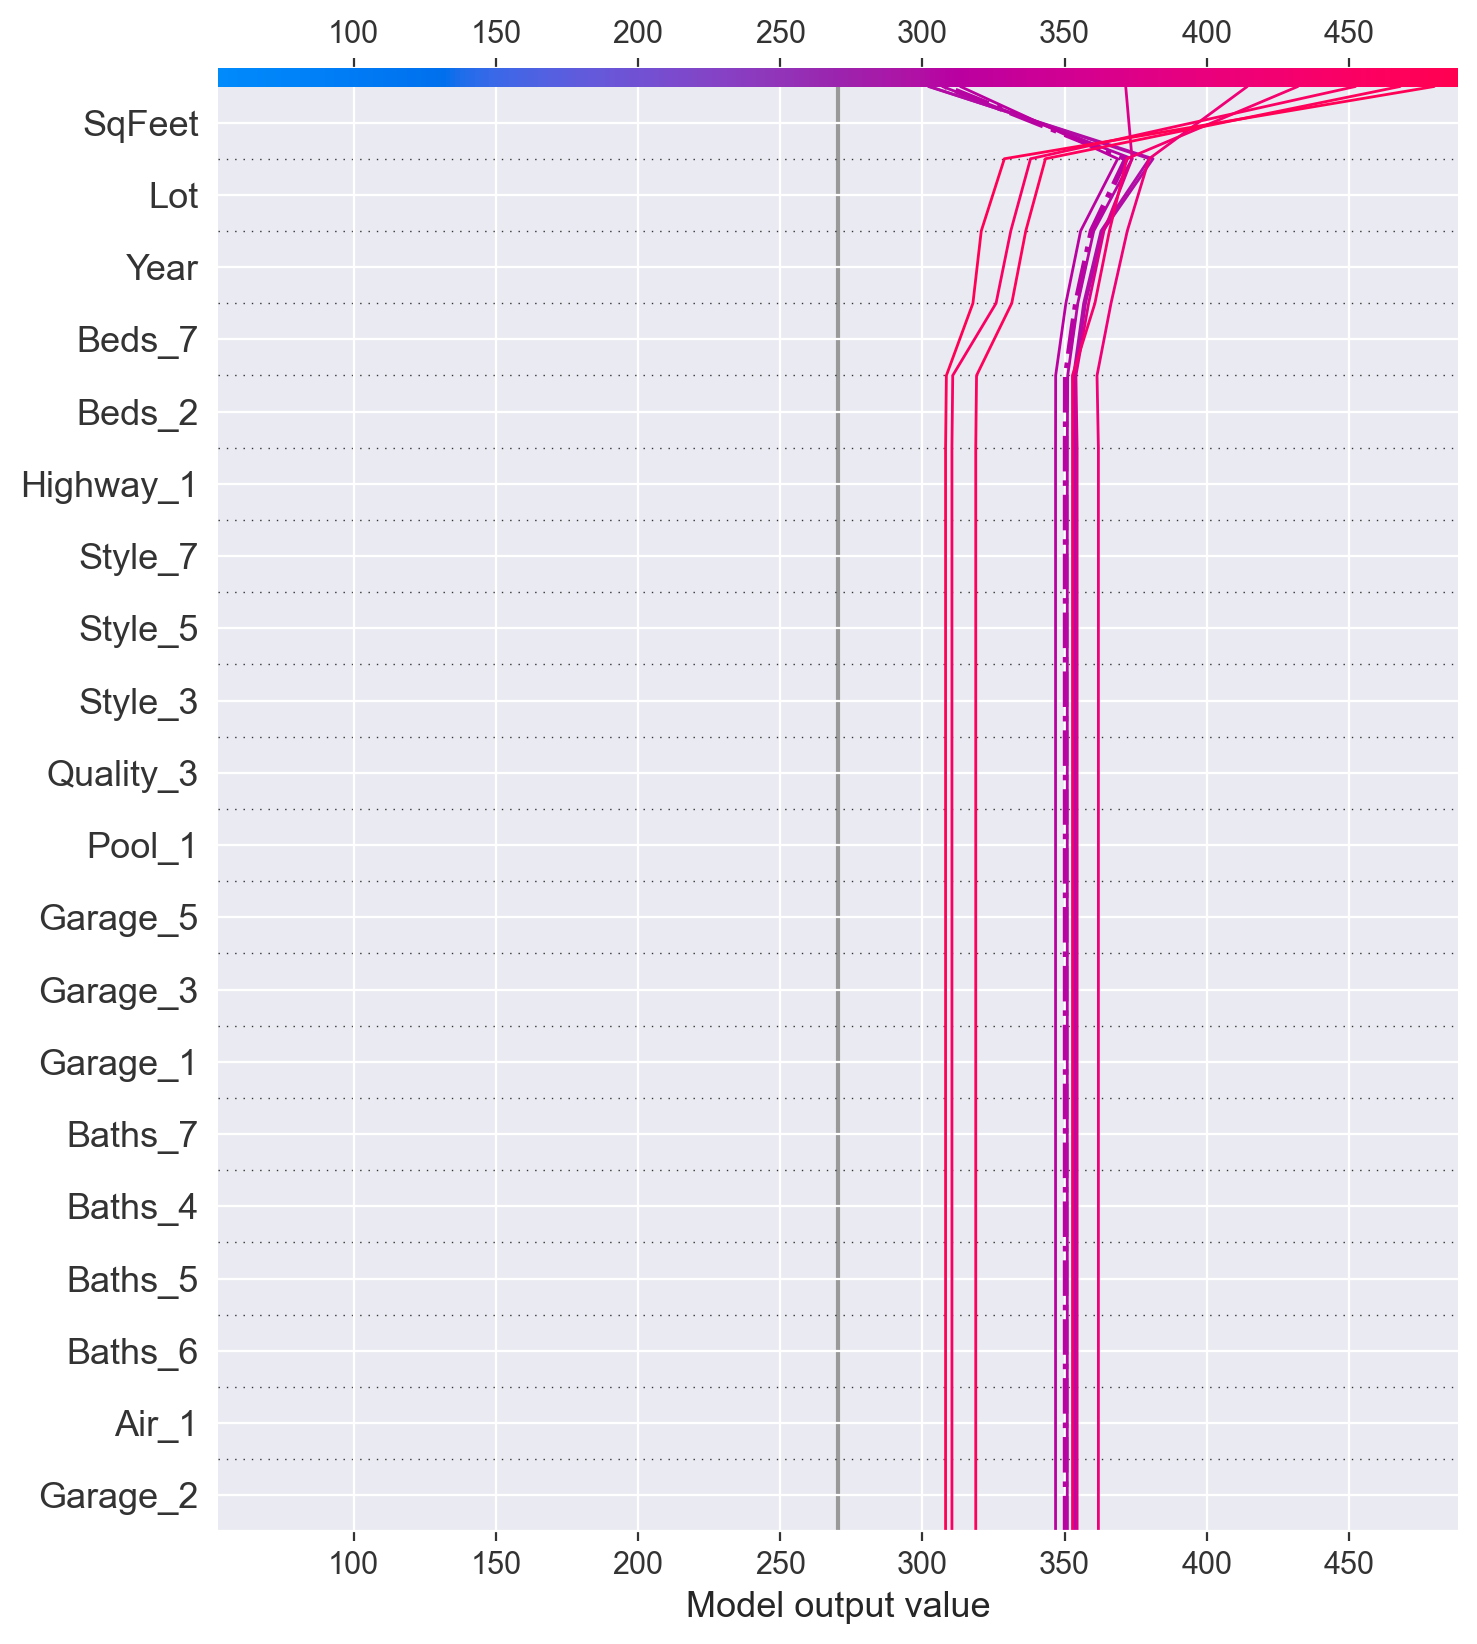

In [68]:
idx = 5
n_scenarios = 10
target_col = 'SqFeet'
original_sample = X_test_ohe.iloc[idx: idx+1].copy()

# Создаем выборку, заменяя значение признака на выбранную из интервала (+- половина всего интервала значений столбца)
original_val = original_sample[target_col].values[0]

val_min = X_train[target_col].min()
val_max = X_train[target_col].max()
val_range = val_max - val_min

values = np.linspace(
    max(val_min, original_val - 0.5 * val_range),
    min(val_max, original_val + 0.5 * val_range),
    n_scenarios
)

hypothetical_samples = []
for val in values:
    sample = original_sample.copy()
    sample[target_col] = val
    hypothetical_samples.append(sample)

hypothetical_df = pd.concat(hypothetical_samples, ignore_index=True)

all_samples = pd.concat([original_sample, hypothetical_df], ignore_index=True)
all_shap_values = explainer.shap_values(all_samples)

original_idx_in_all = 0

shap.decision_plot(
    explainer.expected_value,
    all_shap_values,
    all_samples,
    highlight=[original_idx_in_all],
    feature_order="hclust", #  features are ordered via hierarchical clustering to group similar prediction paths 
)


Перейдем к глобальной интерпретации. Ее можно провести, построив общий график, где каждая точка будет соответствовать одному семплу.

In [69]:
X_train_sc.shape # очень много семплов!

(13314, 10)

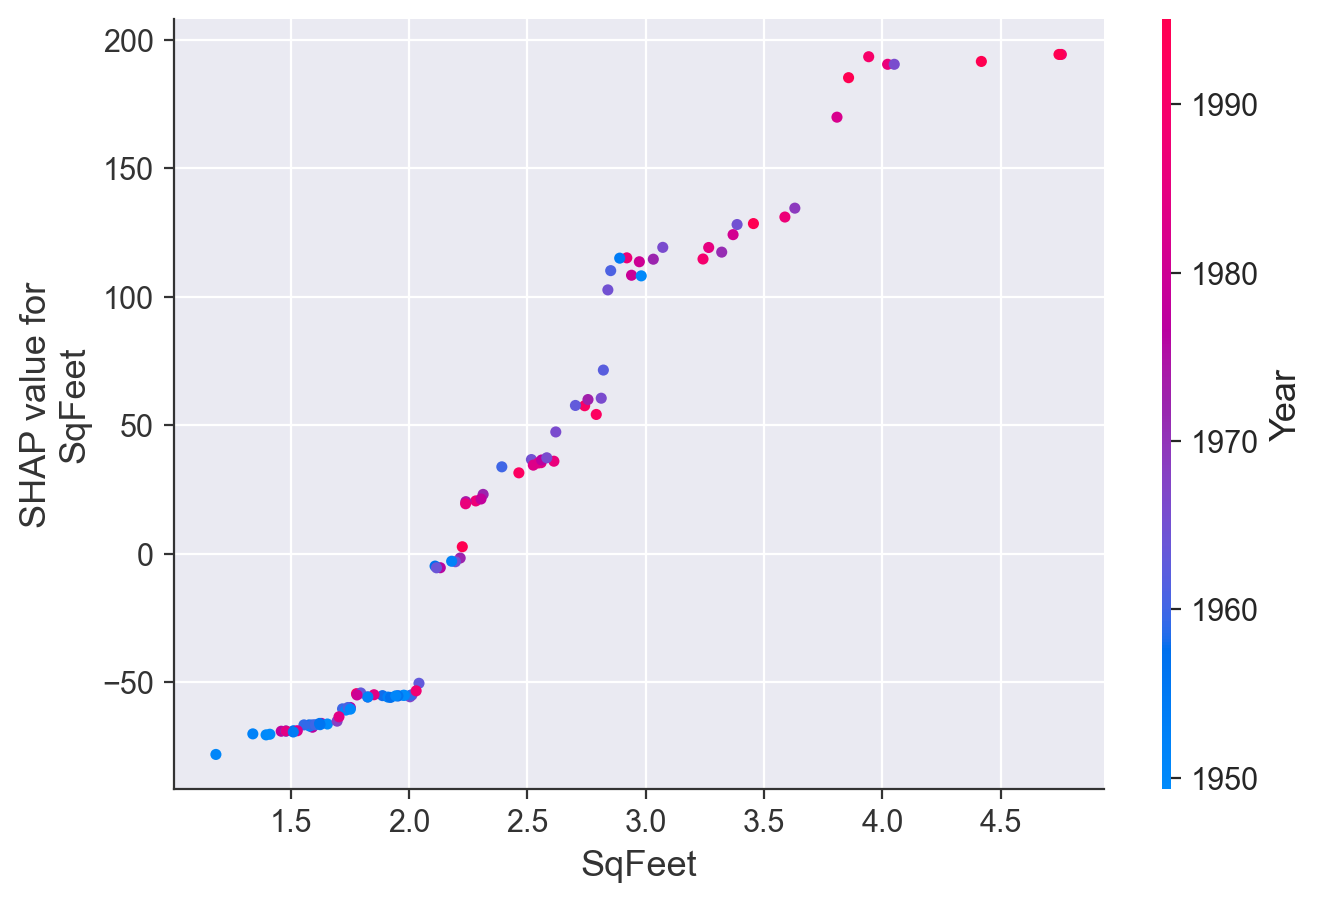

In [70]:
shap.dependence_plot("SqFeet", shap_values.values[:100], X_train_sc_df[:100], interaction_index="Year")

In [71]:
# глобальное поведение через force plot
shap.initjs()

#Посмотрим на график для первых 100 объектов тренировочного набора данных
shap.plots.force(shap_values[:100])

На графике — наблюдения, отсортированные в выбранном порядке (панель сверху). По умолчанию наблюдения остортированы по близости друг к другу (и по оси x — номер наблюдения в отсортированном ряду), а по оси y располагается прогноз модели.

Для y отображения можно выбирать различные признаки — и тогда будет видно, как конкретный признак менял output модели.

Иногда мы не знаем заранее, какой признак мы хотим вывести. Поэтому можно отрисовать самый важный по мнению Shap. В таком случае, мы хотим узнать глобальную важность признака как среднее значение shap и отсортировать признаки по этому значению (в целом, мы так в принципе можем автоматизировать выбор признака). Заодно посмотри на более простой график значений shap.

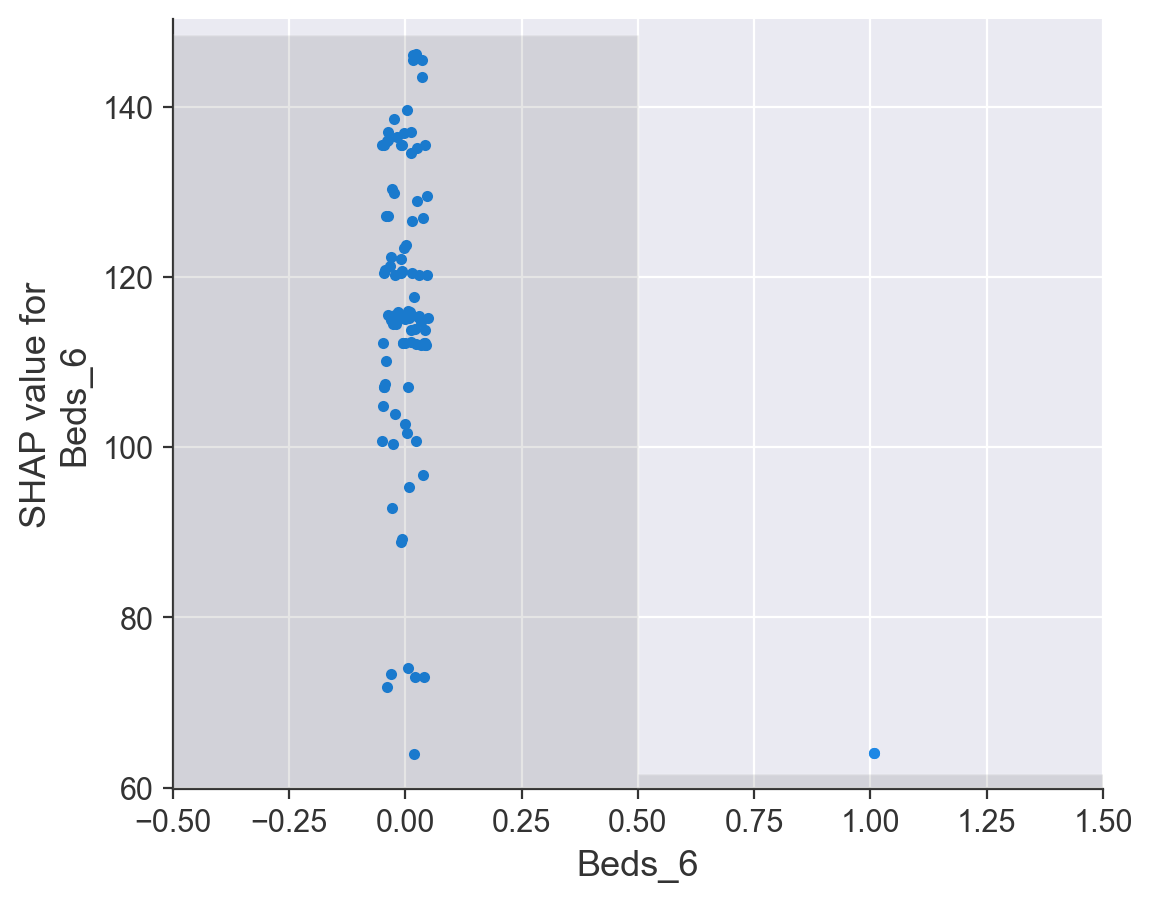

In [72]:
shap.plots.scatter(shap_values[:100,  shap_values.abs.mean(0).argsort[-1]])

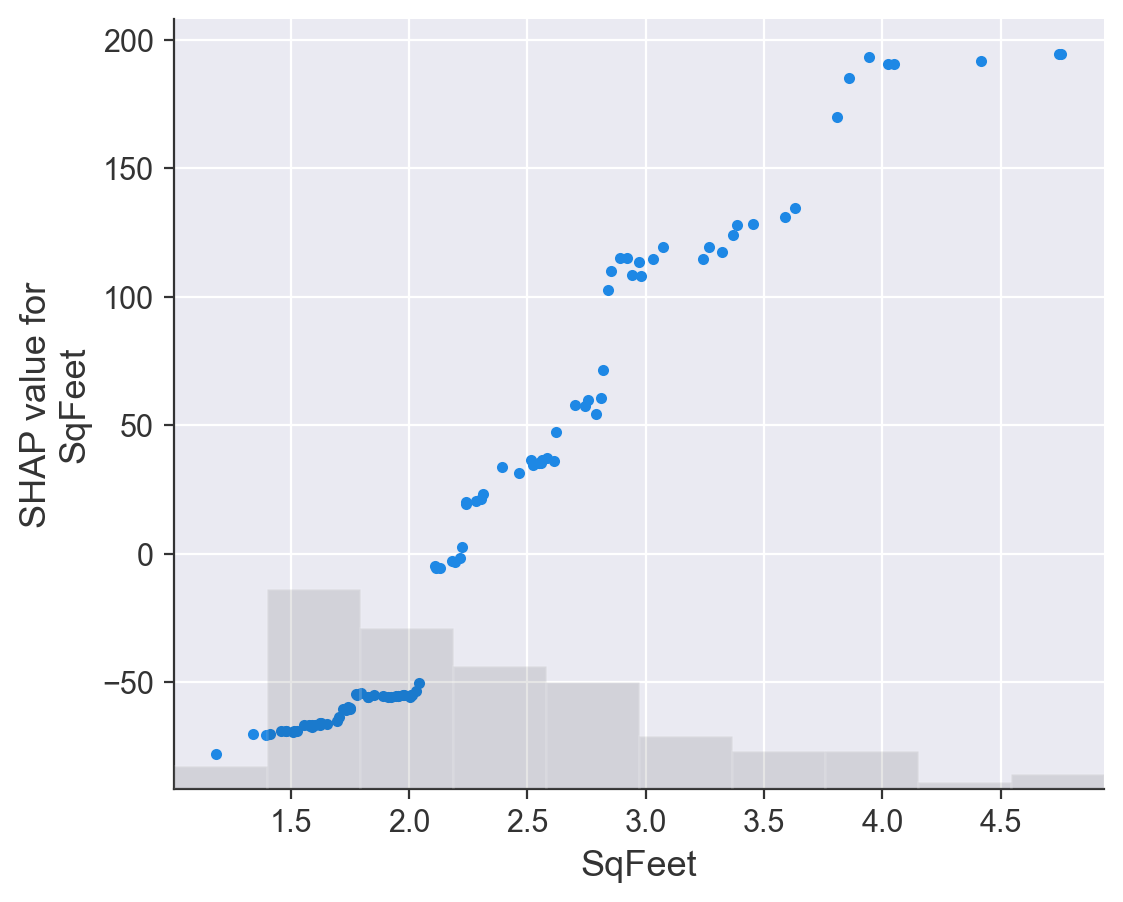

In [73]:
# Второй по важности
shap.plots.scatter(shap_values[:100,  shap_values.abs.mean(0).argsort[-2]])

Мы можем также и узнать взаимодействие двух признаков - отрисовать значения для 1 признака, раскрасив график с помощью второго:


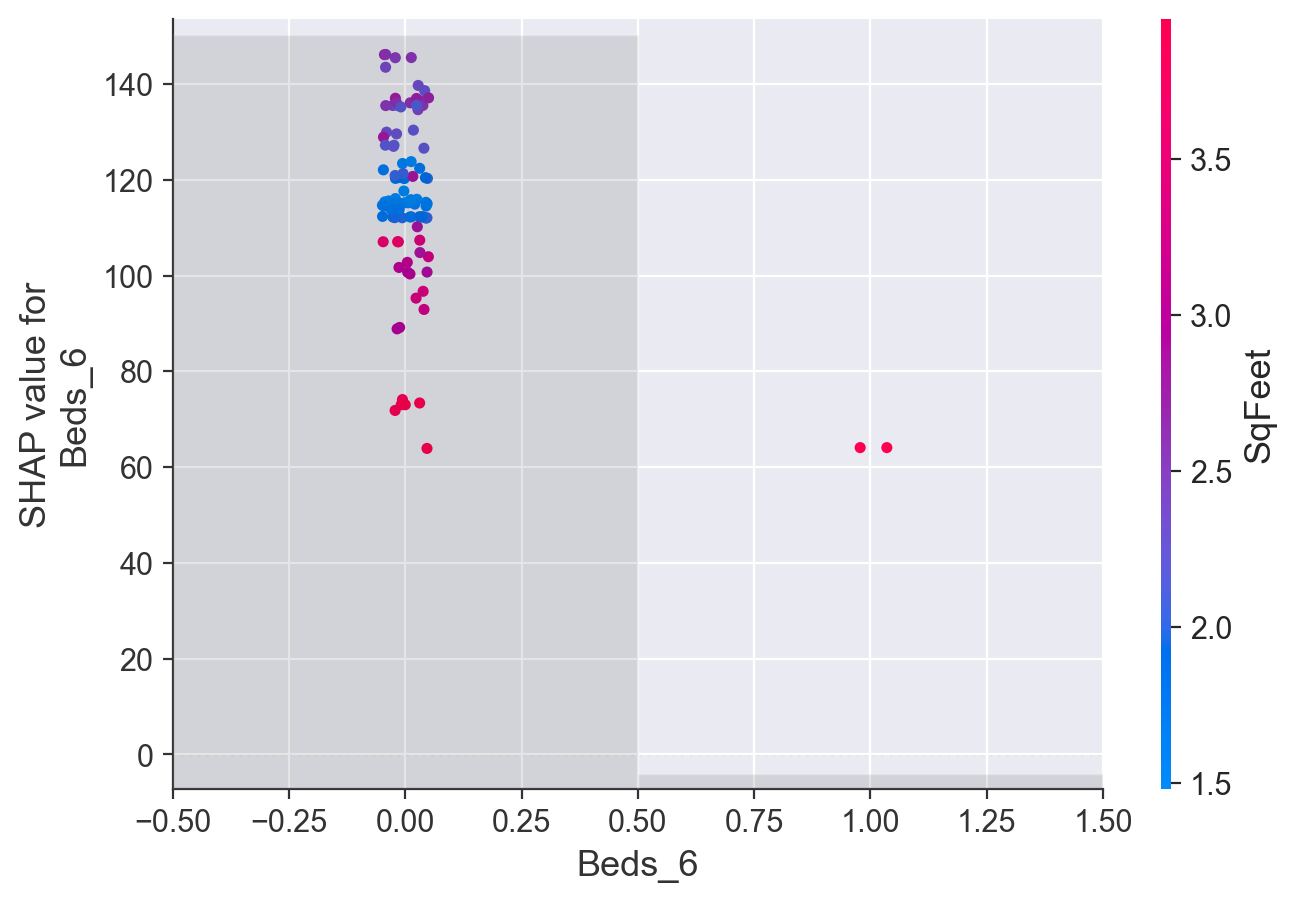

In [74]:
shap.plots.scatter(shap_values[:100,  shap_values.abs.mean(0).argsort[-1]], color = shap_values[:100,  shap_values.abs.mean(0).argsort[-2]])

**Задание:** постройте интерпретацию и для других признаков (хотя бы пары). Сделайте выводы об их влиянии на прогноз в целом и нескольких примеров.

Основной недостаток метода - вычислительная сложность, так как для n признаков необходимо перебрать $2^n$ подмножеств. Для больших n используются приближенные алгоритмы (KernelShap, TreeShap).

Year
Значение: 1984.00
SHAP: 5.4976


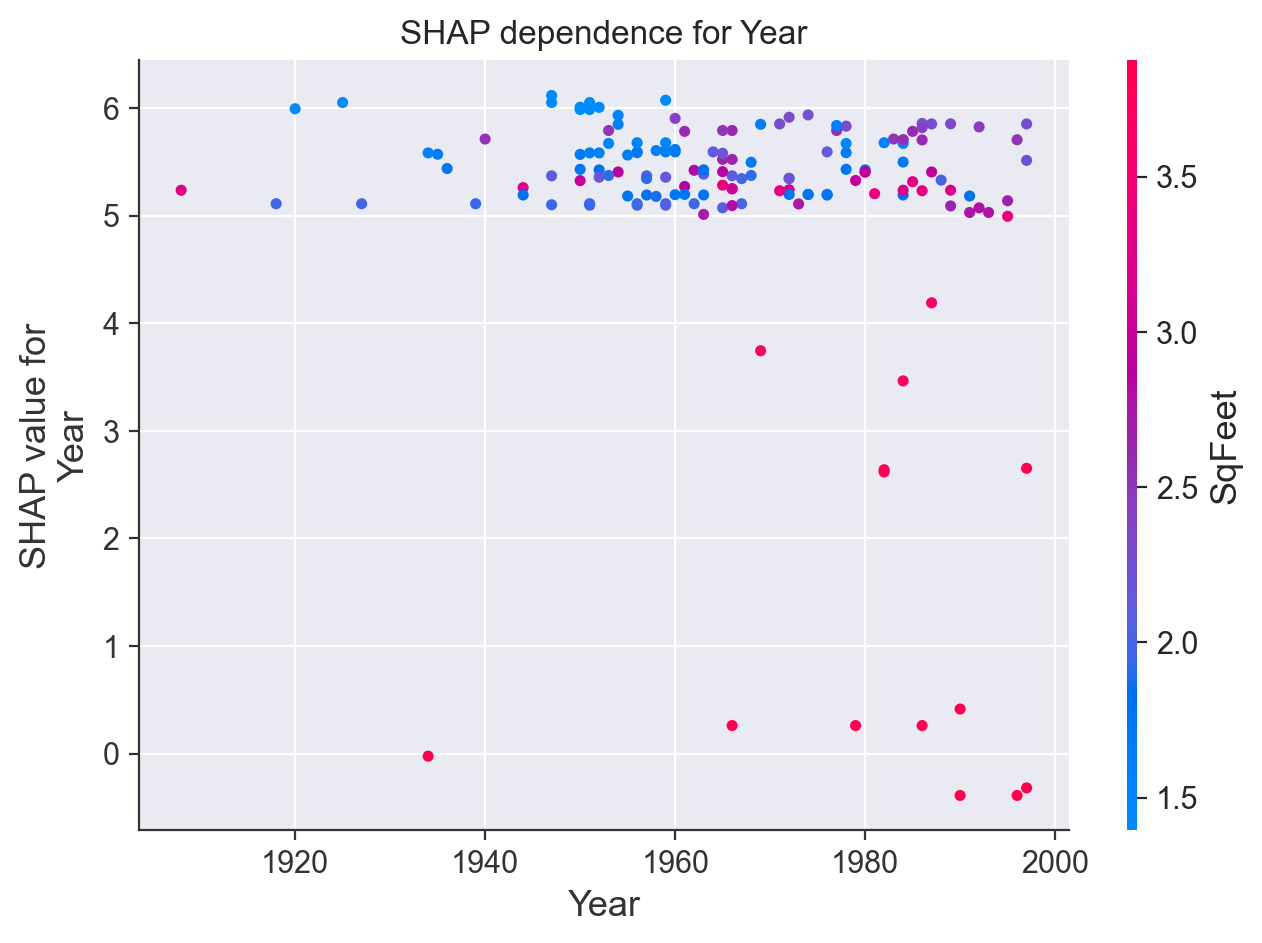

Пример 0: 6.0058
Пример 10: 5.1820
Пример 20: 5.1085
Lot
Значение: 22.58
SHAP: 12.1461


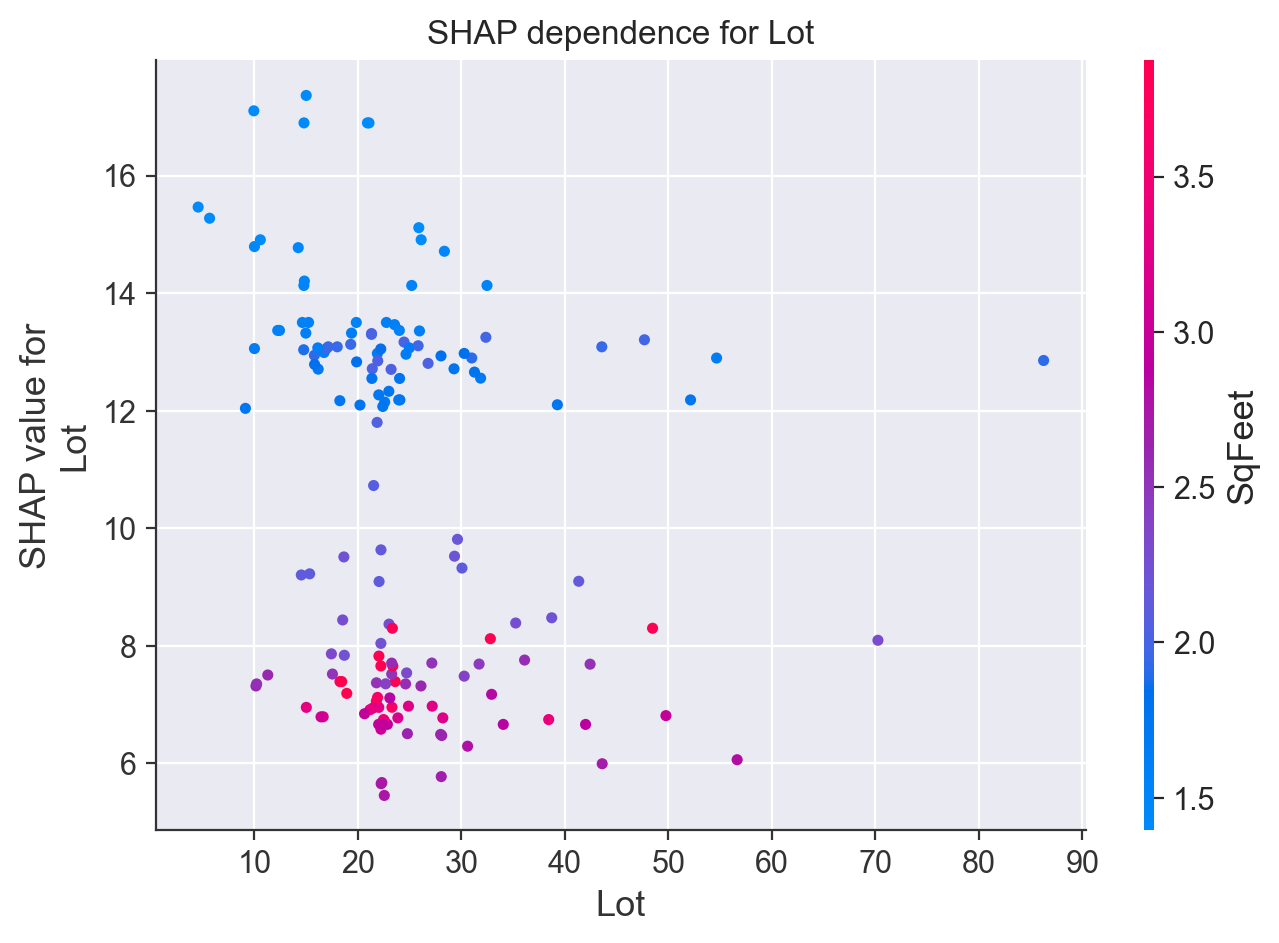

Пример 0: 15.2736
Пример 10: 12.5481
Пример 20: 5.4540
Важность признаков
   feature  importance
7   Beds_6  115.769943
0   SqFeet   70.738286
9  Baths_2   24.011340
6   Beds_5   10.512404
2      Lot   10.382931


In [75]:
X_test_ohe = pd.concat([X_test[["SqFeet","Year","Lot"]], cat_df], axis=1)

explainer = shap.TreeExplainer(model, feature_names=X_test_ohe.columns)
shap_values = explainer.shap_values(X_test_ohe)

features = ['Year', 'Lot']
feature_indices = [X_test_ohe.columns.get_loc(f) for f in features]
idx = 5  

for i, feature in enumerate(features):
    print(feature)
    
    print(f"Значение: {X_test_ohe.iloc[idx][feature]:.2f}")
    print(f"SHAP: {shap_values[idx][feature_indices[i]]:.4f}")
    
    shap.dependence_plot(feature_indices[i], shap_values, X_test_ohe.values, 
                         feature_names=X_test_ohe.columns.tolist(), show=False)
    plt.title(f"SHAP dependence for {feature}")
    plt.show()
    
    for ex in [0, 10, 20]:
        print(f"Пример {ex}: {shap_values[ex][feature_indices[i]]:.4f}")

print("Важность признаков")
imp = pd.DataFrame({
    'feature': X_test_ohe.columns,
    'importance': np.abs(shap_values).mean(0)
}).sort_values('importance', ascending=False)
print(imp.head(5))